In [75]:
import json

with open("/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path.json", "r") as f:
    json_res = json.load(f)

print(json_res[0])


{'question_id': None, 'path': [{'question_id': 1471, 'db_id': 'debit_card_specializing', 'gt_query': "SELECT CAST(SUM(CASE WHEN Currency = 'EUR' THEN 1 ELSE 0 END) AS REAL) / NULLIF(SUM(CASE WHEN Currency = 'CZK' THEN 1 ELSE 0 END), 0) FROM customers", 'predicted_query': "SELECT     SUM(CASE WHEN currency = 'EUR' THEN 1 ELSE 0 END)::FLOAT   NULLIF(SUM(CASE WHEN currency = 'CZK' THEN 1 ELSE 0 END), 0) AS ratio_eur_to_czk FROM     customers", 'correct': None, 'error': 'syntax error at or near "("\nLINE 1: ...urrency = \'EUR\' THEN 1 ELSE 0 END)::FLOAT   NULLIF(SUM(CASE ...\n                                                             ^\n', 'difficulty': 'simple'}]}


In [76]:
import json

with open("/Users/hmmoore/Desktop/mini_dev/llm/data/mini_dev_postgresql_partial_4_turbo_june_2025.json", "r") as f:
    json_gt = json.load(f)

print(json_gt[0])

{'question_id': 1471, 'db_id': 'debit_card_specializing', 'question': 'What is the ratio of customers who pay in EUR against customers who pay in CZK?', 'evidence': "ratio of customers who pay in EUR against customers who pay in CZK = count(Currency = 'EUR') / count(Currency = 'CZK').", 'SQL': "SELECT CAST(SUM(CASE WHEN Currency = 'EUR' THEN 1 ELSE 0 END) AS REAL) / NULLIF(SUM(CASE WHEN Currency = 'CZK' THEN 1 ELSE 0 END), 0) FROM customers", 'difficulty': 'simple', 'is_original': True}


🚀 Starting JSON Correlation Analysis...
✅ Successfully loaded 500 records
✅ Flattened data into 1236 rows and 13 columns

Data quality check:
  - Null values handled: 0
  - Records with correct=1: 380
  - Records with correct=0: 856
  - Records with hallucinations: 703

📊 BASIC STATISTICS
Total questions: 1236
Correct predictions: 380 (30.74%)
Questions with hallucinations: 703 (56.88%)
Questions with errors: 409 (33.09%)

Difficulty distribution:
difficulty
moderate       647
simple         331
challenging    258
Name: count, dtype: int64

Database distribution:
db_id
formula_1                182
thrombosis_prediction    139
card_games               137
european_football_2      117
student_club             115
superhero                115
codebase_community       101
toxicology                91
financial                 88
california_schools        79
Name: count, dtype: int64

🎯 DIFFICULTY CORRELATIONS
Correctness by difficulty:
                 mean  count
difficulty               

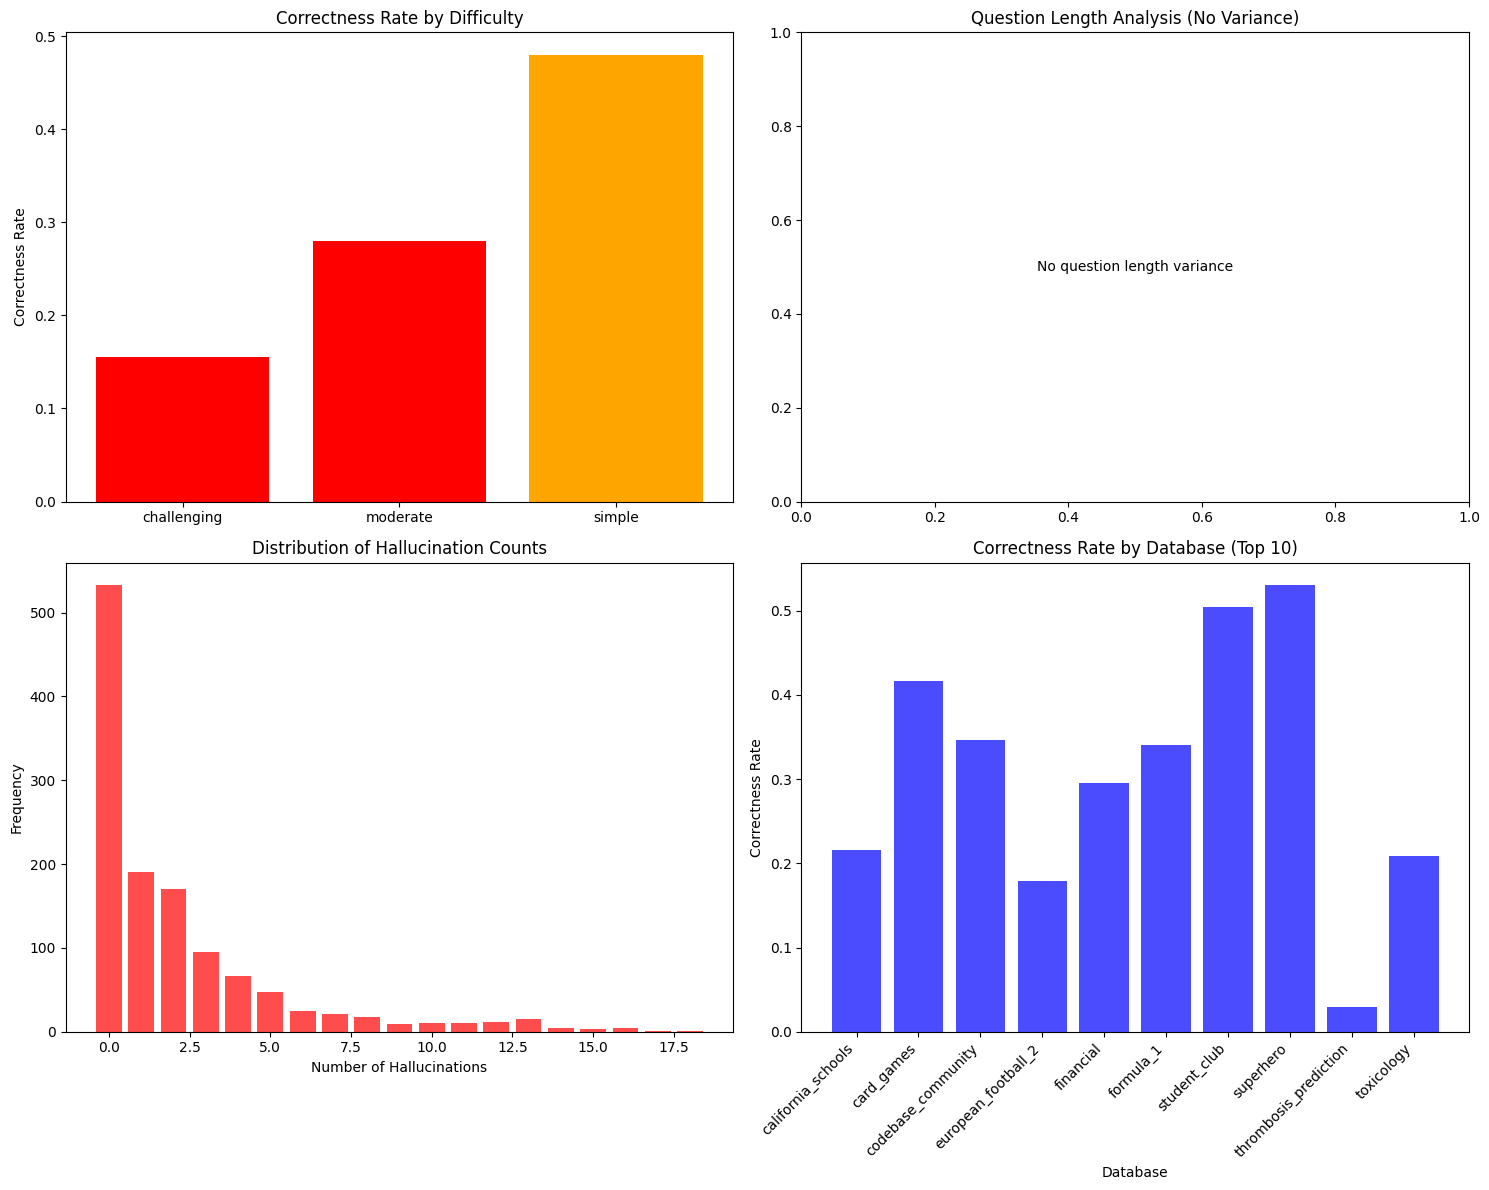

✅ Visualizations saved as 'correlation_analysis.png'

📋 CORRELATION SUMMARY REPORT
🔍 SIGNIFICANT CORRELATIONS FOUND:
  • hallucination_count_correctness: p-value = 0.0000
  • predicted_query_length_correctness: p-value = 0.0000
  • difficulty_correctness: p-value = 0.0000
  • gt_query_length_correctness: p-value = 0.0000

💡 KEY INSIGHTS:
  • Overall accuracy: 30.74%
  • Questions with hallucinations: 56.88%
  • Accuracy by difficulty: {'challenging': np.float64(0.155), 'moderate': np.float64(0.28), 'simple': np.float64(0.48)}

🎯 RECOMMENDATIONS:
  • Focus on improving performance for complex queries
  • Investigate hallucination patterns in specific databases
  • Consider query length as a complexity factor
  • Analyze error patterns by question type

✅ Analysis complete!

Processed dataframe shape: (1236, 14)
Available columns: ['question_id', 'db_id', 'correct', 'difficulty', 'has_error', 'question_length', 'gt_query_length', 'predicted_query_length', 'has_hallucination', 'hallucinat

In [77]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from scipy.stats import chi2_contingency, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

class JSONCorrelationAnalyzer:
    def __init__(self, json_file_path):
        self.json_file_path = json_file_path
        self.data = None
        self.df = None
        self.correlations = {}
        
    def load_data(self):
        """Load and parse JSON data"""
        try:
            with open(self.json_file_path, 'r') as f:
                self.data = json.load(f)
            print(f"✅ Successfully loaded {len(self.data)} records")
            return True
        except Exception as e:
            print(f"❌ Error loading data: {e}")
            return False
    
    def flatten_data(self):
        """Flatten nested JSON structure into tabular format"""
        flattened_records = []
        
        for record in self.data:
            if 'path' in record and record['path']:
                for path_item in record['path']:
                    # Safe conversion function for potentially null values
                    def safe_int(value, default=0):
                        if value is None:
                            return default
                        try:
                            return int(value)
                        except (ValueError, TypeError):
                            return default
                    
                    def safe_len(value, default=0):
                        if value is None:
                            return default
                        try:
                            return len(str(value))
                        except:
                            return default
                    
                    flat_record = {
                        'question_id': path_item.get('question_id'),
                        'db_id': path_item.get('db_id', 'unknown'),
                        'correct': safe_int(path_item.get('correct'), 0),
                        'difficulty': path_item.get('difficulty', 'unknown'),
                        'has_error': 1 if path_item.get('error') else 0,
                        'question_length': safe_len(path_item.get('question')),
                        'gt_query_length': safe_len(path_item.get('gt_query')),
                        'predicted_query_length': safe_len(path_item.get('predicted_query')),
                        'has_hallucination': 1 if path_item.get('hallucination') else 0,
                        'hallucination_count': len(path_item.get('hallucination', [])),
                    }
                    
                    # Extract hallucination types
                    if path_item.get('hallucination'):
                        hallucination_types = [h[0] for h in path_item['hallucination'] if len(h) > 0]
                        flat_record['hallucination_types'] = ', '.join(hallucination_types)
                        
                        # Count specific hallucination categories
                        for h_type in hallucination_types:
                            category = h_type.split(':')[0].strip()
                            safe_category = category.lower().replace("-", "_").replace(" ", "_")
                            flat_record[f'has_{safe_category}_hallucination'] = 1
                    else:
                        flat_record['hallucination_types'] = 'None'
                    
                    flattened_records.append(flat_record)
        
        self.df = pd.DataFrame(flattened_records)
        
        # Clean and fill missing values
        self.df = self.df.fillna(0)
        
        # Ensure numeric columns are properly typed
        numeric_cols = ['correct', 'has_error', 'question_length', 'gt_query_length', 
                       'predicted_query_length', 'has_hallucination', 'hallucination_count']
        
        for col in numeric_cols:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce').fillna(0)
        
        # Fill NaN values for hallucination columns
        hallucination_cols = [col for col in self.df.columns if col.startswith('has_') and col.endswith('_hallucination')]
        for col in hallucination_cols:
            self.df[col] = self.df[col].fillna(0).astype(int)
        
        # Remove any remaining NaN or infinite values
        self.df = self.df.replace([np.inf, -np.inf], np.nan).fillna(0)
        
        print(f"✅ Flattened data into {len(self.df)} rows and {len(self.df.columns)} columns")
        
        # Show some data quality info
        print(f"\nData quality check:")
        print(f"  - Null values handled: {self.df.isnull().sum().sum()}")
        print(f"  - Records with correct=1: {self.df['correct'].sum()}")
        print(f"  - Records with correct=0: {(self.df['correct'] == 0).sum()}")
        print(f"  - Records with hallucinations: {self.df['has_hallucination'].sum()}")
        
        return self.df
    
    def basic_statistics(self):
        """Generate basic statistics"""
        print("\n" + "="*50)
        print("📊 BASIC STATISTICS")
        print("="*50)
        
        print(f"Total questions: {len(self.df)}")
        print(f"Correct predictions: {self.df['correct'].sum()} ({self.df['correct'].mean():.2%})")
        print(f"Questions with hallucinations: {self.df['has_hallucination'].sum()} ({self.df['has_hallucination'].mean():.2%})")
        print(f"Questions with errors: {self.df['has_error'].sum()} ({self.df['has_error'].mean():.2%})")
        
        print(f"\nDifficulty distribution:")
        print(self.df['difficulty'].value_counts())
        
        print(f"\nDatabase distribution:")
        print(self.df['db_id'].value_counts().head(10))
    
    def analyze_difficulty_correlation(self):
        """Analyze correlation between difficulty and other factors"""
        print("\n" + "="*50)
        print("🎯 DIFFICULTY CORRELATIONS")
        print("="*50)
        
        # Map difficulty to numeric values
        difficulty_map = {'easy': 1, 'moderate': 2, 'hard': 3}
        self.df['difficulty_numeric'] = self.df['difficulty'].map(difficulty_map)
        
        # Correlation with correctness
        difficulty_correctness = self.df.groupby('difficulty')['correct'].agg(['mean', 'count'])
        print("Correctness by difficulty:")
        print(difficulty_correctness)
        
        # Chi-square test for difficulty vs correctness
        contingency_table = pd.crosstab(self.df['difficulty'], self.df['correct'])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        print(f"\nChi-square test (difficulty vs correctness):")
        print(f"Chi-square statistic: {chi2:.4f}")
        print(f"P-value: {p_value:.4f}")
        print(f"Significant correlation: {'Yes' if p_value < 0.05 else 'No'}")
        
        self.correlations['difficulty_correctness'] = {
            'chi2': chi2,
            'p_value': p_value,
            'significant': p_value < 0.05
        }
    
    def analyze_length_correlations(self):
        """Analyze correlations involving text lengths"""
        print("\n" + "="*50)
        print("📏 LENGTH CORRELATIONS")
        print("="*50)
        
        length_cols = ['question_length', 'gt_query_length', 'predicted_query_length']
        
        # Check for valid data before correlation analysis
        valid_cols = []
        for col in length_cols:
            if col in self.df.columns:
                # Check for valid variance (not all same values)
                if self.df[col].std() > 0 and not self.df[col].isnull().all():
                    valid_cols.append(col)
                else:
                    print(f"⚠️ Skipping {col}: no variance or all null values")
        
        if not valid_cols:
            print("❌ No valid length columns for correlation analysis")
            return
        
        # Correlation matrix for lengths
        try:
            corr_cols = valid_cols + ['correct', 'has_hallucination']
            length_corr = self.df[corr_cols].corr()
            print("Length correlation matrix:")
            print(length_corr.round(3))
        except Exception as e:
            print(f"⚠️ Could not create correlation matrix: {e}")
        
        # Specific correlations with error handling
        for col in valid_cols:
            try:
                # Ensure no NaN or infinite values
                x = self.df[col].dropna()
                y_correct = self.df.loc[x.index, 'correct']
                y_halluc = self.df.loc[x.index, 'has_hallucination']
                
                if len(x) > 1 and x.std() > 0:
                    corr_correct, p_correct = pearsonr(x, y_correct)
                    corr_halluc, p_halluc = pearsonr(x, y_halluc)
                    
                    print(f"\n{col}:")
                    print(f"  vs Correctness: r={corr_correct:.3f}, p={p_correct:.4f}")
                    print(f"  vs Hallucination: r={corr_halluc:.3f}, p={p_halluc:.4f}")
                    
                    self.correlations[f'{col}_correctness'] = {
                        'correlation': corr_correct,
                        'p_value': p_correct,
                        'significant': p_correct < 0.05
                    }
                else:
                    print(f"⚠️ Insufficient data for {col} correlation")
            except Exception as e:
                print(f"⚠️ Error analyzing {col}: {e}")
    
    def analyze_hallucination_patterns(self):
        """Analyze hallucination type patterns"""
        print("\n" + "="*50)
        print("👻 HALLUCINATION PATTERNS")
        print("="*50)
        
        # Hallucination type frequency
        hallucination_types = []
        for types_str in self.df['hallucination_types'].dropna():
            if types_str != 'None' and str(types_str) != 'nan':
                types_list = [t.strip() for t in str(types_str).split(',')]
                hallucination_types.extend(types_list)
        
        if hallucination_types:
            type_counts = Counter(hallucination_types)
            print("Most common hallucination types:")
            for h_type, count in type_counts.most_common(10):
                print(f"  {h_type}: {count}")
        else:
            print("No hallucination types found in data")
        
        # Correlation between hallucination count and correctness
        try:
            if 'hallucination_count' in self.df.columns:
                # Clean the data
                halluc_data = self.df['hallucination_count'].dropna()
                correct_data = self.df.loc[halluc_data.index, 'correct']
                
                if len(halluc_data) > 1 and halluc_data.std() > 0:
                    corr, p_value = pearsonr(halluc_data, correct_data)
                    print(f"\nHallucination count vs Correctness:")
                    print(f"Correlation: {corr:.3f}, P-value: {p_value:.4f}")
                    
                    self.correlations['hallucination_count_correctness'] = {
                        'correlation': corr,
                        'p_value': p_value,
                        'significant': p_value < 0.05
                    }
                else:
                    print("Insufficient variance in hallucination count for correlation")
        except Exception as e:
            print(f"⚠️ Error in hallucination correlation analysis: {e}")
    
    def analyze_database_patterns(self):
        """Analyze patterns by database"""
        print("\n" + "="*50)
        print("🗄️ DATABASE PATTERNS")
        print("="*50)
        
        db_stats = self.df.groupby('db_id').agg({
            'correct': ['mean', 'count'],
            'has_hallucination': 'mean',
            'question_length': 'mean'
        }).round(3)
        
        print("Top 10 databases by question count:")
        db_stats_sorted = db_stats.sort_values(('correct', 'count'), ascending=False)
        print(db_stats_sorted.head(10))
        
        # Find databases with unusual patterns
        print("\nDatabases with lowest correctness rates:")
        lowest_correct = db_stats.sort_values(('correct', 'mean')).head(5)
        print(lowest_correct)
        
        print("\nDatabases with highest hallucination rates:")
        highest_halluc = db_stats.sort_values(('has_hallucination', 'mean'), ascending=False).head(5)
        print(highest_halluc)
    
    def create_visualizations(self):
        """Create correlation visualizations"""
        print("\n" + "="*50)
        print("📈 CREATING VISUALIZATIONS")
        print("="*50)
        
        try:
            fig, axes = plt.subplots(2, 2, figsize=(15, 12))
            
            # 1. Difficulty vs Correctness
            if 'difficulty' in self.df.columns and self.df['difficulty'].notna().any():
                difficulty_correct = self.df.groupby('difficulty')['correct'].mean()
                colors = ['green' if x > 0.7 else 'orange' if x > 0.4 else 'red' for x in difficulty_correct.values]
                axes[0, 0].bar(difficulty_correct.index, difficulty_correct.values, color=colors)
                axes[0, 0].set_title('Correctness Rate by Difficulty')
                axes[0, 0].set_ylabel('Correctness Rate')
            else:
                axes[0, 0].text(0.5, 0.5, 'No difficulty data', ha='center', va='center')
                axes[0, 0].set_title('Difficulty Analysis (No Data)')
            
            # 2. Question Length vs Correctness
            if 'question_length' in self.df.columns and self.df['question_length'].std() > 0:
                axes[0, 1].scatter(self.df['question_length'], self.df['correct'], alpha=0.6)
                axes[0, 1].set_title('Question Length vs Correctness')
                axes[0, 1].set_xlabel('Question Length')
                axes[0, 1].set_ylabel('Correct (1=Yes, 0=No)')
            else:
                axes[0, 1].text(0.5, 0.5, 'No question length variance', ha='center', va='center')
                axes[0, 1].set_title('Question Length Analysis (No Variance)')
            
            # 3. Hallucination Count Distribution
            if 'hallucination_count' in self.df.columns:
                halluc_counts = self.df['hallucination_count'].value_counts().sort_index()
                if len(halluc_counts) > 0:
                    axes[1, 0].bar(halluc_counts.index, halluc_counts.values, color='red', alpha=0.7)
                    axes[1, 0].set_title('Distribution of Hallucination Counts')
                    axes[1, 0].set_xlabel('Number of Hallucinations')
                    axes[1, 0].set_ylabel('Frequency')
                else:
                    axes[1, 0].text(0.5, 0.5, 'No hallucination data', ha='center', va='center')
                    axes[1, 0].set_title('Hallucination Distribution (No Data)')
            
            # 4. Database Performance
            if 'db_id' in self.df.columns and self.df['db_id'].notna().any():
                top_dbs = self.df['db_id'].value_counts().head(10).index
                if len(top_dbs) > 0:
                    db_correct = self.df[self.df['db_id'].isin(top_dbs)].groupby('db_id')['correct'].mean()
                    axes[1, 1].bar(range(len(db_correct)), db_correct.values, color='blue', alpha=0.7)
                    axes[1, 1].set_title('Correctness Rate by Database (Top 10)')
                    axes[1, 1].set_xlabel('Database')
                    axes[1, 1].set_ylabel('Correctness Rate')
                    axes[1, 1].set_xticks(range(len(db_correct)))
                    axes[1, 1].set_xticklabels(db_correct.index, rotation=45, ha='right')
                else:
                    axes[1, 1].text(0.5, 0.5, 'No database data', ha='center', va='center')
                    axes[1, 1].set_title('Database Analysis (No Data)')
            
            plt.tight_layout()
            plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print("✅ Visualizations saved as 'correlation_analysis.png'")
            
        except Exception as e:
            print(f"⚠️ Error creating visualizations: {e}")
            print("Continuing with text-based analysis...")
    
    def summary_report(self):
        """Generate summary of key findings"""
        print("\n" + "="*50)
        print("📋 CORRELATION SUMMARY REPORT")
        print("="*50)
        
        significant_correlations = []
        
        for key, stats in self.correlations.items():
            if stats.get('significant', False):
                significant_correlations.append({
                    'correlation': key,
                    'strength': abs(stats.get('correlation', stats.get('chi2', 0))),
                    'p_value': stats.get('p_value', 1)
                })
        
        if significant_correlations:
            print("🔍 SIGNIFICANT CORRELATIONS FOUND:")
            for corr in sorted(significant_correlations, key=lambda x: x['p_value']):
                print(f"  • {corr['correlation']}: p-value = {corr['p_value']:.4f}")
        else:
            print("No statistically significant correlations found at α = 0.05")
        
        # Key insights
        print("\n💡 KEY INSIGHTS:")
        print(f"  • Overall accuracy: {self.df['correct'].mean():.2%}")
        print(f"  • Questions with hallucinations: {self.df['has_hallucination'].mean():.2%}")
        
        if 'difficulty' in self.df.columns:
            diff_acc = self.df.groupby('difficulty')['correct'].mean()
            print(f"  • Accuracy by difficulty: {dict(diff_acc.round(3))}")
        
        # Recommendations
        print("\n🎯 RECOMMENDATIONS:")
        print("  • Focus on improving performance for complex queries")
        print("  • Investigate hallucination patterns in specific databases")
        print("  • Consider query length as a complexity factor")
        print("  • Analyze error patterns by question type")
    
    def run_full_analysis(self):
        """Run complete correlation analysis"""
        print("🚀 Starting JSON Correlation Analysis...")
        
        if not self.load_data():
            return
        
        self.flatten_data()
        self.basic_statistics()
        self.analyze_difficulty_correlation()
        self.analyze_length_correlations()
        self.analyze_hallucination_patterns()
        self.analyze_database_patterns()
        self.create_visualizations()
        self.summary_report()
        
        print("\n✅ Analysis complete!")
        return self.df, self.correlations

# Example usage:
if __name__ == "__main__":
    # Replace 'your_file.json' with your actual JSON file path
    analyzer = JSONCorrelationAnalyzer('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc.json')
    df, correlations = analyzer.run_full_analysis()
    
    # You can also access the processed dataframe for further analysis
    print(f"\nProcessed dataframe shape: {df.shape}")
    print(f"Available columns: {list(df.columns)}")

🚀 Starting Path-Based Hallucination Analysis...
✅ Loaded 500 path sequences

🛣️  PATH STRUCTURE ANALYSIS
Total paths: 500
Paths with hallucinations: 383 (76.60%)
Average path length: 2.47
Path length range: 1 to 6

Path length distribution:
  Length 1: 45 paths
  Length 2: 237 paths
  Length 3: 161 paths
  Length 4: 52 paths
  Length 5: 4 paths
  Length 6: 1 paths

📍 HALLUCINATION POSITION PATTERNS
Hallucination frequency by step position:
  Position 0: 293/500 (58.60%) have hallucinations
  Position 1: 257/455 (56.48%) have hallucinations
  Position 2: 121/218 (55.50%) have hallucinations
  Position 3: 30/57 (52.63%) have hallucinations
  Position 4: 1/5 (20.00%) have hallucinations
  Position 5: 1/1 (100.00%) have hallucinations

First hallucination positions:
  Position 0: 293 paths
  Position 1: 72 paths
  Position 2: 16 paths
  Position 3: 1 paths
  Position 5: 1 paths

Hallucination streak lengths:
  1 consecutive steps: 179 occurrences
  2 consecutive steps: 140 occurrences
  3 

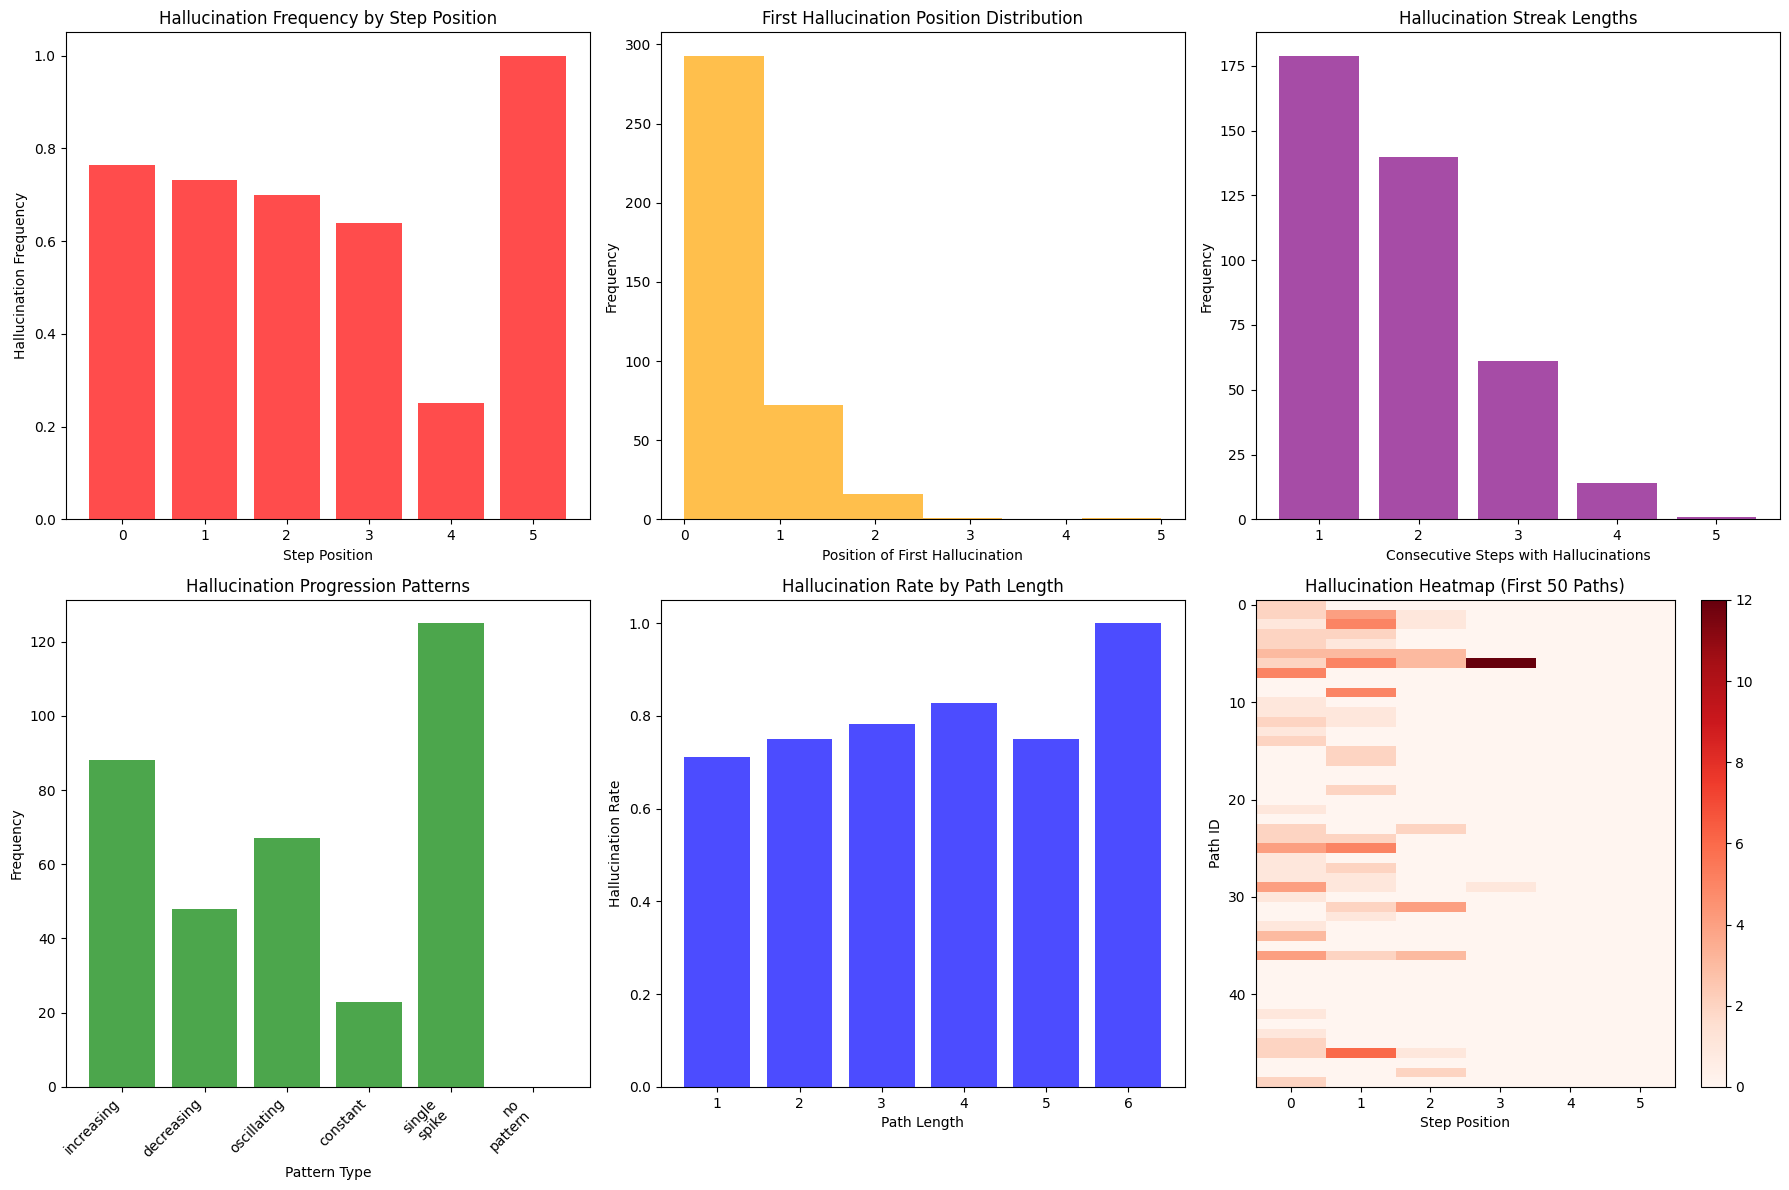

✅ Visualizations saved as 'path_hallucination_analysis.png'

📋 PATH HALLUCINATION SUMMARY REPORT
🔍 KEY FINDINGS:
  • 383/500 paths contain hallucinations (76.60%)
  • First hallucination appears at position 0.3 on average
  • Average hallucination streak: 1.8 steps
  • Maximum hallucination streak: 5 steps
  • Most common progression pattern: single spike (125 paths)

✅ Path analysis complete!


In [78]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

class PathHallucinationAnalyzer:
    def __init__(self, json_file_path):
        self.json_file_path = json_file_path
        self.data = None
        self.path_analysis = []
        self.hallucination_patterns = {}
        
    def load_data(self):
        """Load JSON data"""
        try:
            with open(self.json_file_path, 'r') as f:
                self.data = json.load(f)
            print(f"✅ Loaded {len(self.data)} path sequences")
            return True
        except Exception as e:
            print(f"❌ Error loading data: {e}")
            return False
    
    def analyze_path_structure(self):
        """Analyze the structure and progression of paths"""
        print("\n" + "="*60)
        print("🛣️  PATH STRUCTURE ANALYSIS")
        print("="*60)

        # Safe conversion function for potentially null values
        def safe_int(value, default=0):
            if value is None:
                return default
            try:
                return int(value)
            except (ValueError, TypeError):
                return default
        
        path_lengths = []
        paths_with_hallucinations = 0
        
        for i, record in enumerate(self.data):
            if 'path' in record and record['path']:
                path_length = len(record['path'])
                path_lengths.append(path_length)
                
                # Check if this path contains any hallucinations
                has_hallucination = any(step.get('hallucination') for step in record['path'])
                if has_hallucination:
                    paths_with_hallucinations += 1
                
                # Store path info for detailed analysis
                path_info = {
                    'path_id': i,
                    'length': path_length,
                    'has_hallucination': has_hallucination,
                    'steps': []
                }
                
                for step_idx, step in enumerate(record['path']):
                    step_info = {
                        'step_position': step_idx,
                        'question_id': step.get('question_id'),
                        'correct': safe_int(step.get('correct', 0)),
                        'has_hallucination': bool(step.get('hallucination')),
                        'hallucination_count': len(step.get('hallucination', [])),
                        'hallucination_types': []
                    }
                    
                    if step.get('hallucination'):
                        step_info['hallucination_types'] = [h[0] for h in step['hallucination'] if len(h) > 0]
                    
                    path_info['steps'].append(step_info)
                
                self.path_analysis.append(path_info)
        
        print(f"Total paths: {len(path_lengths)}")
        print(f"Paths with hallucinations: {paths_with_hallucinations} ({paths_with_hallucinations/len(path_lengths):.2%})")
        print(f"Average path length: {np.mean(path_lengths):.2f}")
        print(f"Path length range: {min(path_lengths)} to {max(path_lengths)}")
        
        # Path length distribution
        length_dist = Counter(path_lengths)
        print(f"\nPath length distribution:")
        for length in sorted(length_dist.keys()):
            print(f"  Length {length}: {length_dist[length]} paths")
    
    def analyze_hallucination_position_patterns(self):
        """Analyze where hallucinations occur within paths"""
        print("\n" + "="*60)
        print("📍 HALLUCINATION POSITION PATTERNS")
        print("="*60)
        
        position_hallucinations = defaultdict(list)  # position -> list of hallucination counts
        first_hallucination_positions = []
        last_hallucination_positions = []
        hallucination_streaks = []
        
        for path in self.path_analysis:
            if path['has_hallucination']:
                # Track hallucinations by position
                halluc_positions = []
                for step in path['steps']:
                    position_hallucinations[step['step_position']].append(step['hallucination_count'])
                    if step['has_hallucination']:
                        halluc_positions.append(step['step_position'])
                
                if halluc_positions:
                    first_hallucination_positions.append(halluc_positions[0])
                    last_hallucination_positions.append(halluc_positions[-1])
                    
                    # Calculate streak lengths
                    streaks = []
                    current_streak = 0
                    for step in path['steps']:
                        if step['has_hallucination']:
                            current_streak += 1
                        else:
                            if current_streak > 0:
                                streaks.append(current_streak)
                                current_streak = 0
                    if current_streak > 0:
                        streaks.append(current_streak)
                    
                    hallucination_streaks.extend(streaks)
        
        # Position analysis
        print("Hallucination frequency by step position:")
        max_position = max(position_hallucinations.keys()) if position_hallucinations else 0
        for pos in range(max_position + 1):
            if pos in position_hallucinations:
                halluc_counts = position_hallucinations[pos]
                total_steps_at_pos = sum(1 for path in self.path_analysis if len(path['steps']) > pos)
                steps_with_halluc = sum(1 for count in halluc_counts if count > 0)
                if total_steps_at_pos > 0:
                    print(f"  Position {pos}: {steps_with_halluc}/{total_steps_at_pos} ({steps_with_halluc/total_steps_at_pos:.2%}) have hallucinations")
        
        # First/Last hallucination analysis
        if first_hallucination_positions:
            print(f"\nFirst hallucination positions:")
            first_dist = Counter(first_hallucination_positions)
            for pos in sorted(first_dist.keys()):
                print(f"  Position {pos}: {first_dist[pos]} paths")
        
        if hallucination_streaks:
            print(f"\nHallucination streak lengths:")
            streak_dist = Counter(hallucination_streaks)
            for length in sorted(streak_dist.keys()):
                print(f"  {length} consecutive steps: {streak_dist[length]} occurrences")
        
        self.hallucination_patterns['position_patterns'] = {
            'position_hallucinations': dict(position_hallucinations),
            'first_positions': first_hallucination_positions,
            'streak_lengths': hallucination_streaks
        }
    
    def analyze_hallucination_progression(self):
        """Analyze how hallucinations change through the path"""
        print("\n" + "="*60)
        print("📈 HALLUCINATION PROGRESSION ANALYSIS")
        print("="*60)
        
        progression_patterns = {
            'increasing': 0,      # hallucinations increase over time
            'decreasing': 0,      # hallucinations decrease over time
            'oscillating': 0,     # hallucinations go up and down
            'constant': 0,        # hallucinations stay roughly the same
            'single_spike': 0,    # one step with hallucinations
            'no_pattern': 0       # no clear pattern
        }
        
        for path in self.path_analysis:
            if len(path['steps']) <= 1:
                continue
                
            halluc_counts = [step['hallucination_count'] for step in path['steps']]
            
            if sum(halluc_counts) == 0:
                continue
            elif sum(1 for x in halluc_counts if x > 0) == 1:
                progression_patterns['single_spike'] += 1
                continue
            
            # Analyze trend
            differences = [halluc_counts[i+1] - halluc_counts[i] for i in range(len(halluc_counts)-1)]
            
            if not differences:
                continue
            
            increases = sum(1 for d in differences if d > 0)
            decreases = sum(1 for d in differences if d < 0)
            
            if increases > decreases * 2:
                progression_patterns['increasing'] += 1
            elif decreases > increases * 2:
                progression_patterns['decreasing'] += 1
            elif increases > 0 and decreases > 0:
                progression_patterns['oscillating'] += 1
            elif increases == 0 and decreases == 0:
                progression_patterns['constant'] += 1
            else:
                progression_patterns['no_pattern'] += 1
        
        print("Hallucination progression patterns:")
        total_patterns = sum(progression_patterns.values())
        for pattern, count in progression_patterns.items():
            if total_patterns > 0:
                print(f"  {pattern.replace('_', ' ').title()}: {count} ({count/total_patterns:.2%})")
        
        self.hallucination_patterns['progression'] = progression_patterns
    
    def analyze_correctness_vs_hallucination_relationship(self):
        """Analyze relationship between correctness and hallucinations in paths"""
        print("\n" + "="*60)
        print("✅❌ CORRECTNESS vs HALLUCINATION RELATIONSHIP")
        print("="*60)
        
        relationships = {
            'correct_then_hallucinate': 0,    # starts correct, then gets hallucinations
            'hallucinate_then_correct': 0,    # starts with hallucinations, then becomes correct
            'always_correct_no_halluc': 0,    # always correct, no hallucinations
            'always_incorrect_with_halluc': 0, # always incorrect with hallucinations
            'mixed_pattern': 0                # complex mixed pattern
        }
        
        step_transitions = []  # Track step-to-step transitions
        
        for path in self.path_analysis:
            if len(path['steps']) <= 1:
                continue
            
            correct_sequence = [step['correct'] for step in path['steps']]
            halluc_sequence = [step['has_hallucination'] for step in path['steps']]
            
            # Analyze overall pattern
            all_correct = all(correct_sequence)
            any_hallucination = any(halluc_sequence)
            
            if all_correct and not any_hallucination:
                relationships['always_correct_no_halluc'] += 1
            elif not any(correct_sequence) and any_hallucination:
                relationships['always_incorrect_with_halluc'] += 1
            else:
                # Look for transitions
                first_half_correct = sum(correct_sequence[:len(correct_sequence)//2]) > len(correct_sequence)//4
                second_half_halluc = sum(halluc_sequence[len(halluc_sequence)//2:]) > 0
                
                first_half_halluc = sum(halluc_sequence[:len(halluc_sequence)//2]) > 0
                second_half_correct = sum(correct_sequence[len(correct_sequence)//2:]) > len(correct_sequence)//4
                
                if first_half_correct and second_half_halluc:
                    relationships['correct_then_hallucinate'] += 1
                elif first_half_halluc and second_half_correct:
                    relationships['hallucinate_then_correct'] += 1
                else:
                    relationships['mixed_pattern'] += 1
            
            # Track step-to-step transitions
            for i in range(len(path['steps'])-1):
                current = path['steps'][i]
                next_step = path['steps'][i+1]
                
                transition = {
                    'from_correct': current['correct'],
                    'from_halluc': current['has_hallucination'],
                    'to_correct': next_step['correct'],
                    'to_halluc': next_step['has_hallucination']
                }
                step_transitions.append(transition)
        
        print("Path-level patterns:")
        total_patterns = sum(relationships.values())
        for pattern, count in relationships.items():
            if total_patterns > 0:
                print(f"  {pattern.replace('_', ' ').title()}: {count} ({count/total_patterns:.2%})")
        
        # Transition analysis
        if step_transitions:
            print(f"\nStep-to-step transitions (n={len(step_transitions)}):")
            transition_types = defaultdict(int)
            
            for trans in step_transitions:
                key = f"{'Correct' if trans['from_correct'] else 'Incorrect'}+{'Halluc' if trans['from_halluc'] else 'NoHalluc'} → {'Correct' if trans['to_correct'] else 'Incorrect'}+{'Halluc' if trans['to_halluc'] else 'NoHalluc'}"
                transition_types[key] += 1
            
            for trans_type, count in sorted(transition_types.items(), key=lambda x: x[1], reverse=True):
                print(f"  {trans_type}: {count} ({count/len(step_transitions):.2%})")
    
    def analyze_hallucination_types_progression(self):
        """Analyze how hallucination types change through paths"""
        print("\n" + "="*60)
        print("🏷️  HALLUCINATION TYPE PROGRESSION")
        print("="*60)
        
        type_progressions = defaultdict(list)  # type -> list of positions where it occurs
        type_transitions = defaultdict(int)     # from_type -> to_type transitions
        
        for path in self.path_analysis:
            prev_types = set()
            
            for step_idx, step in enumerate(path['steps']):
                if step['hallucination_types']:
                    current_types = set(step['hallucination_types'])
                    
                    # Track positions for each type
                    for h_type in current_types:
                        type_progressions[h_type].append(step_idx)
                    
                    # Track type transitions
                    if prev_types and current_types != prev_types:
                        for prev_type in prev_types:
                            for curr_type in current_types:
                                if prev_type != curr_type:
                                    type_transitions[f"{prev_type} → {curr_type}"] += 1
                    
                    prev_types = current_types
        
        print("Most common hallucination types by position:")
        all_types = list(type_progressions.keys())
        if all_types:
            for h_type in sorted(all_types, key=lambda x: len(type_progressions[x]), reverse=True)[:10]:
                positions = type_progressions[h_type]
                avg_position = np.mean(positions)
                print(f"  {h_type}: {len(positions)} occurrences, avg position {avg_position:.1f}")
        
        if type_transitions:
            print(f"\nMost common hallucination type transitions:")
            for transition, count in sorted(type_transitions.items(), key=lambda x: x[1], reverse=True)[:10]:
                print(f"  {transition}: {count} times")
    
    def create_visualizations(self):
        """Create visualizations for path-based hallucination patterns"""
        print("\n" + "="*60)
        print("📊 CREATING PATH VISUALIZATIONS")
        print("="*60)
        
        try:
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            
            # 1. Hallucination frequency by position
            position_data = self.hallucination_patterns.get('position_patterns', {}).get('position_hallucinations', {})
            if position_data:
                positions = list(range(max(position_data.keys()) + 1))
                frequencies = []
                for pos in positions:
                    if pos in position_data:
                        halluc_counts = position_data[pos]
                        freq = sum(1 for count in halluc_counts if count > 0) / len(halluc_counts) if halluc_counts else 0
                    else:
                        freq = 0
                    frequencies.append(freq)
                
                axes[0, 0].bar(positions, frequencies, color='red', alpha=0.7)
                axes[0, 0].set_title('Hallucination Frequency by Step Position')
                axes[0, 0].set_xlabel('Step Position')
                axes[0, 0].set_ylabel('Hallucination Frequency')
            
            # 2. First hallucination position distribution
            first_positions = self.hallucination_patterns.get('position_patterns', {}).get('first_positions', [])
            if first_positions:
                axes[0, 1].hist(first_positions, bins=max(first_positions)+1, color='orange', alpha=0.7)
                axes[0, 1].set_title('First Hallucination Position Distribution')
                axes[0, 1].set_xlabel('Position of First Hallucination')
                axes[0, 1].set_ylabel('Frequency')
            
            # 3. Streak length distribution
            streaks = self.hallucination_patterns.get('position_patterns', {}).get('streak_lengths', [])
            if streaks:
                streak_counts = Counter(streaks)
                axes[0, 2].bar(streak_counts.keys(), streak_counts.values(), color='purple', alpha=0.7)
                axes[0, 2].set_title('Hallucination Streak Lengths')
                axes[0, 2].set_xlabel('Consecutive Steps with Hallucinations')
                axes[0, 2].set_ylabel('Frequency')
            
            # 4. Progression patterns
            progression_data = self.hallucination_patterns.get('progression', {})
            if progression_data:
                patterns = list(progression_data.keys())
                counts = list(progression_data.values())
                axes[1, 0].bar(range(len(patterns)), counts, color='green', alpha=0.7)
                axes[1, 0].set_title('Hallucination Progression Patterns')
                axes[1, 0].set_xlabel('Pattern Type')
                axes[1, 0].set_ylabel('Frequency')
                axes[1, 0].set_xticks(range(len(patterns)))
                axes[1, 0].set_xticklabels([p.replace('_', '\n') for p in patterns], rotation=45, ha='right')
            
            # 5. Path length vs hallucination relationship
            path_lengths = [len(path['steps']) for path in self.path_analysis]
            halluc_flags = [path['has_hallucination'] for path in self.path_analysis]
            
            if path_lengths and halluc_flags:
                df_viz = pd.DataFrame({'path_length': path_lengths, 'has_hallucination': halluc_flags})
                halluc_by_length = df_viz.groupby('path_length')['has_hallucination'].mean()
                
                axes[1, 1].bar(halluc_by_length.index, halluc_by_length.values, color='blue', alpha=0.7)
                axes[1, 1].set_title('Hallucination Rate by Path Length')
                axes[1, 1].set_xlabel('Path Length')
                axes[1, 1].set_ylabel('Hallucination Rate')
            
            # 6. Heatmap of hallucinations by position and path
            max_length = max(len(path['steps']) for path in self.path_analysis) if self.path_analysis else 1
            heatmap_data = np.zeros((min(len(self.path_analysis), 50), max_length))  # Limit to first 50 paths for readability
            
            for i, path in enumerate(self.path_analysis[:50]):
                for j, step in enumerate(path['steps']):
                    if j < max_length:
                        heatmap_data[i, j] = step['hallucination_count']
            
            if heatmap_data.max() > 0:
                im = axes[1, 2].imshow(heatmap_data, cmap='Reds', aspect='auto')
                axes[1, 2].set_title('Hallucination Heatmap (First 50 Paths)')
                axes[1, 2].set_xlabel('Step Position')
                axes[1, 2].set_ylabel('Path ID')
                plt.colorbar(im, ax=axes[1, 2])
            
            plt.tight_layout()
            plt.savefig('path_hallucination_analysis.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print("✅ Visualizations saved as 'path_hallucination_analysis.png'")
            
        except Exception as e:
            print(f"⚠️ Error creating visualizations: {e}")
    
    def generate_summary_report(self):
        """Generate comprehensive summary of findings"""
        print("\n" + "="*60)
        print("📋 PATH HALLUCINATION SUMMARY REPORT")
        print("="*60)
        
        total_paths = len(self.path_analysis)
        paths_with_halluc = sum(1 for path in self.path_analysis if path['has_hallucination'])
        
        print(f"🔍 KEY FINDINGS:")
        print(f"  • {paths_with_halluc}/{total_paths} paths contain hallucinations ({paths_with_halluc/total_paths:.2%})")
        
        # Average position analysis
        if self.hallucination_patterns.get('position_patterns', {}).get('first_positions'):
            avg_first_pos = np.mean(self.hallucination_patterns['position_patterns']['first_positions'])
            print(f"  • First hallucination appears at position {avg_first_pos:.1f} on average")
        
        # Streak analysis
        if self.hallucination_patterns.get('position_patterns', {}).get('streak_lengths'):
            avg_streak = np.mean(self.hallucination_patterns['position_patterns']['streak_lengths'])
            max_streak = max(self.hallucination_patterns['position_patterns']['streak_lengths'])
            print(f"  • Average hallucination streak: {avg_streak:.1f} steps")
            print(f"  • Maximum hallucination streak: {max_streak} steps")
        
        # Most common progression pattern
        if self.hallucination_patterns.get('progression'):
            most_common_pattern = max(self.hallucination_patterns['progression'].items(), key=lambda x: x[1])
            print(f"  • Most common progression pattern: {most_common_pattern[0].replace('_', ' ')} ({most_common_pattern[1]} paths)")
        
    
    def run_full_analysis(self):
        """Run complete path-based hallucination analysis"""
        print("🚀 Starting Path-Based Hallucination Analysis...")
        
        if not self.load_data():
            return None
        
        self.analyze_path_structure()
        self.analyze_hallucination_position_patterns()  
        self.analyze_hallucination_progression()
        self.analyze_correctness_vs_hallucination_relationship()
        self.analyze_hallucination_types_progression()
        self.create_visualizations()
        self.generate_summary_report()
        
        print("\n✅ Path analysis complete!")
        return self.path_analysis, self.hallucination_patterns

# Example usage
if __name__ == "__main__":
    analyzer = PathHallucinationAnalyzer('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc.json')
    path_analysis, patterns = analyzer.run_full_analysis()

🚀 Starting Enhanced Path-Based Hallucination Analysis...
✅ Loaded 500 path sequences

🛣️  PATH STRUCTURE ANALYSIS
Total paths: 500
Paths with hallucinations: 383 (76.60%)
Average path length: 2.47
Path length range: 1 to 6

Path length distribution:
  Length 1: 45 paths
  Length 2: 237 paths
  Length 3: 161 paths
  Length 4: 52 paths
  Length 5: 4 paths
  Length 6: 1 paths

📍 HALLUCINATION POSITION PATTERNS
Hallucination frequency by step position:
  Position 0: 293/500 (58.60%) have hallucinations
  Position 1: 257/455 (56.48%) have hallucinations
  Position 2: 121/218 (55.50%) have hallucinations
  Position 3: 30/57 (52.63%) have hallucinations
  Position 4: 1/5 (20.00%) have hallucinations
  Position 5: 1/1 (100.00%) have hallucinations

First hallucination positions:
  Position 0: 293 paths
  Position 1: 72 paths
  Position 2: 16 paths
  Position 3: 1 paths
  Position 5: 1 paths

Hallucination streak lengths:
  1 consecutive steps: 179 occurrences
  2 consecutive steps: 140 occurre

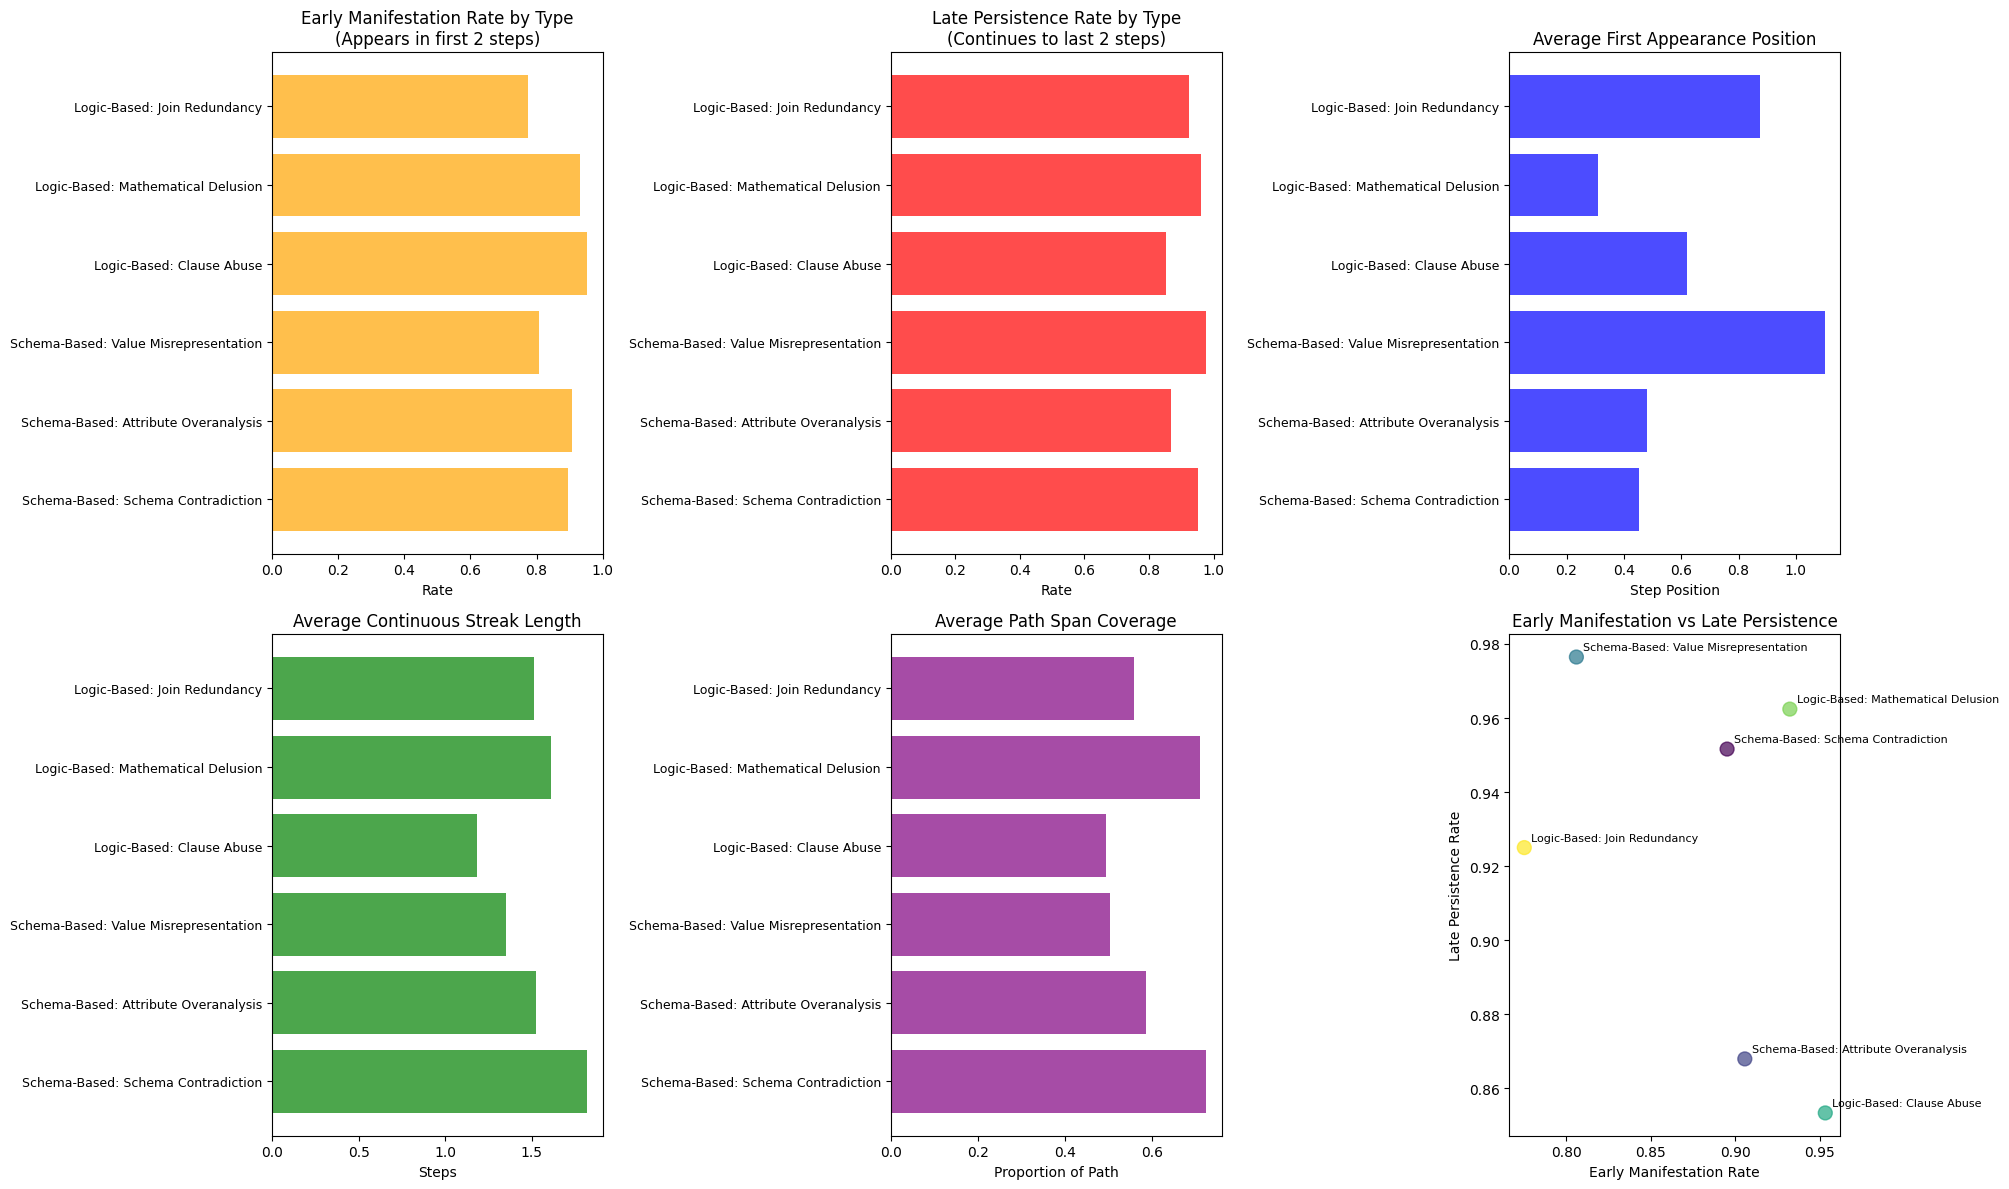

✅ Type persistence visualizations saved as 'hallucination_type_persistence_analysis.png'

📊 CREATING PATH VISUALIZATIONS


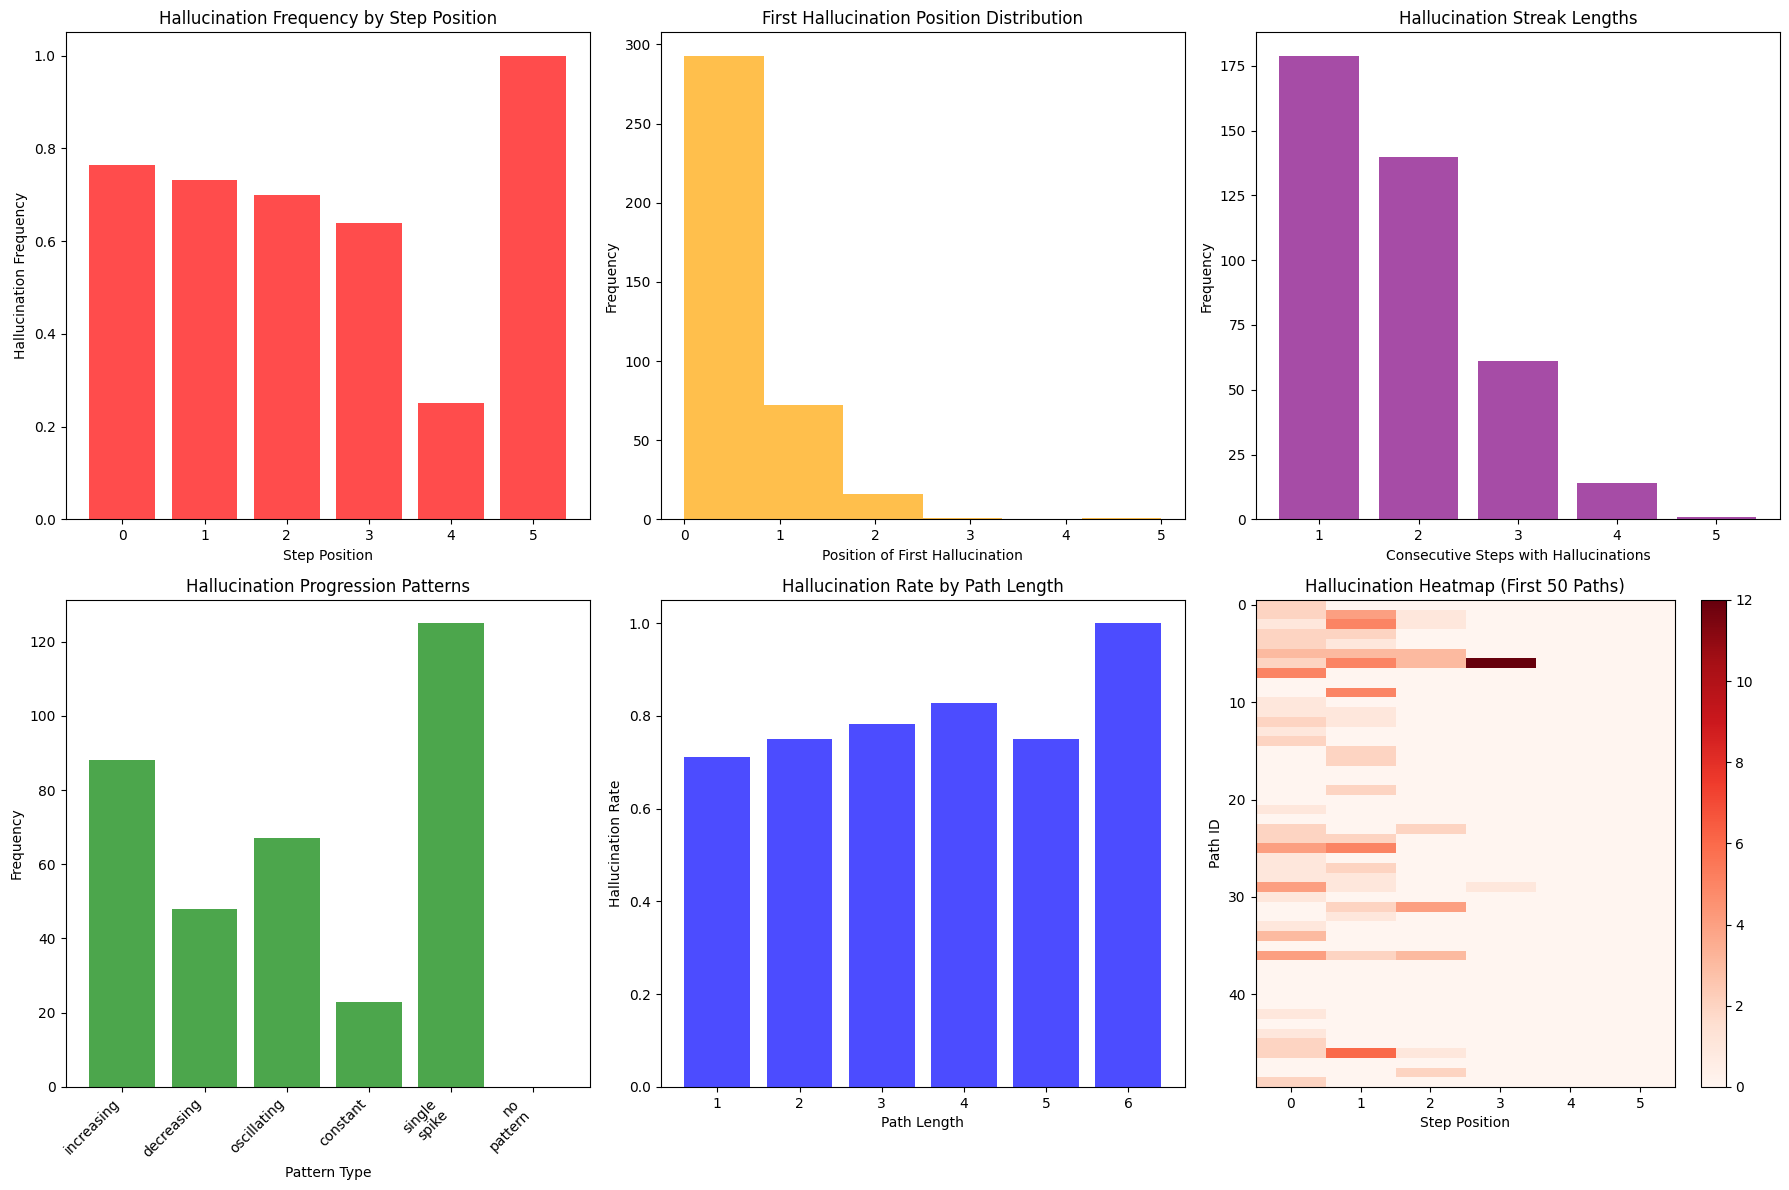

✅ Visualizations saved as 'path_hallucination_analysis.png'

📋 PATH HALLUCINATION SUMMARY REPORT
🔍 KEY FINDINGS:
  • 383/500 paths contain hallucinations (76.60%)
  • First hallucination appears at position 0.3 on average
  • Average hallucination streak: 1.8 steps
  • Maximum hallucination streak: 5 steps
  • Most common progression pattern: single spike (125 paths)
  • Most common hallucination type: Schema-Based: Schema Contradiction (999 occurrences)
  • Most persistent type: Schema-Based: Schema Contradiction (avg 1.8 step streaks)
  • Earliest manifesting type: Logic-Based: Mathematical Delusion (avg position 0.3)

✅ Enhanced path analysis complete!

📊 TOP 10 HALLUCINATION TYPES SUMMARY
Type                      Total  Paths  Avg First  Early%   Late%    Streak  
--------------------------------------------------------------------------------
Schema-Based: Schema...   999    124    0.5        89.5     95.2     1.8     
Schema-Based: Attrib...   558    212    0.5        90.6     8

In [79]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

class PathHallucinationAnalyzer:
    def __init__(self, json_file_path):
        self.json_file_path = json_file_path
        self.data = None
        self.path_analysis = []
        self.hallucination_patterns = {}
        self.type_analysis = {}  # New: detailed type-specific analysis
        
    def load_data(self):
        """Load JSON data"""
        try:
            with open(self.json_file_path, 'r') as f:
                self.data = json.load(f)
            print(f"✅ Loaded {len(self.data)} path sequences")
            return True
        except Exception as e:
            print(f"❌ Error loading data: {e}")
            return False
    
    def analyze_path_structure(self):
        """Analyze the structure and progression of paths"""
        print("\n" + "="*60)
        print("🛣️  PATH STRUCTURE ANALYSIS")
        print("="*60)

        # Safe conversion function for potentially null values
        def safe_int(value, default=0):
            if value is None:
                return default
            try:
                return int(value)
            except (ValueError, TypeError):
                return default
        
        path_lengths = []
        paths_with_hallucinations = 0
        
        for i, record in enumerate(self.data):
            if 'path' in record and record['path']:
                path_length = len(record['path'])
                path_lengths.append(path_length)
                
                # Check if this path contains any hallucinations
                has_hallucination = any(step.get('hallucination') for step in record['path'])
                if has_hallucination:
                    paths_with_hallucinations += 1
                
                # Store path info for detailed analysis
                path_info = {
                    'path_id': i,
                    'length': path_length,
                    'has_hallucination': has_hallucination,
                    'steps': []
                }
                
                for step_idx, step in enumerate(record['path']):
                    step_info = {
                        'step_position': step_idx,
                        'question_id': step.get('question_id'),
                        'correct': safe_int(step.get('correct', 0)),
                        'has_hallucination': bool(step.get('hallucination')),
                        'hallucination_count': len(step.get('hallucination', [])),
                        'hallucination_types': []
                    }
                    
                    if step.get('hallucination'):
                        step_info['hallucination_types'] = [h[0] for h in step['hallucination'] if len(h) > 0]
                    
                    path_info['steps'].append(step_info)
                
                self.path_analysis.append(path_info)
        
        print(f"Total paths: {len(path_lengths)}")
        print(f"Paths with hallucinations: {paths_with_hallucinations} ({paths_with_hallucinations/len(path_lengths):.2%})")
        print(f"Average path length: {np.mean(path_lengths):.2f}")
        print(f"Path length range: {min(path_lengths)} to {max(path_lengths)}")
        
        # Path length distribution
        length_dist = Counter(path_lengths)
        print(f"\nPath length distribution:")
        for length in sorted(length_dist.keys()):
            print(f"  Length {length}: {length_dist[length]} paths")
    
    def analyze_hallucination_position_patterns(self):
        """Analyze where hallucinations occur within paths"""
        print("\n" + "="*60)
        print("📍 HALLUCINATION POSITION PATTERNS")
        print("="*60)
        
        position_hallucinations = defaultdict(list)  # position -> list of hallucination counts
        first_hallucination_positions = []
        last_hallucination_positions = []
        hallucination_streaks = []
        
        for path in self.path_analysis:
            if path['has_hallucination']:
                # Track hallucinations by position
                halluc_positions = []
                for step in path['steps']:
                    position_hallucinations[step['step_position']].append(step['hallucination_count'])
                    if step['has_hallucination']:
                        halluc_positions.append(step['step_position'])
                
                if halluc_positions:
                    first_hallucination_positions.append(halluc_positions[0])
                    last_hallucination_positions.append(halluc_positions[-1])
                    
                    # Calculate streak lengths
                    streaks = []
                    current_streak = 0
                    for step in path['steps']:
                        if step['has_hallucination']:
                            current_streak += 1
                        else:
                            if current_streak > 0:
                                streaks.append(current_streak)
                                current_streak = 0
                    if current_streak > 0:
                        streaks.append(current_streak)
                    
                    hallucination_streaks.extend(streaks)
        
        # Position analysis
        print("Hallucination frequency by step position:")
        max_position = max(position_hallucinations.keys()) if position_hallucinations else 0
        for pos in range(max_position + 1):
            if pos in position_hallucinations:
                halluc_counts = position_hallucinations[pos]
                total_steps_at_pos = sum(1 for path in self.path_analysis if len(path['steps']) > pos)
                steps_with_halluc = sum(1 for count in halluc_counts if count > 0)
                if total_steps_at_pos > 0:
                    print(f"  Position {pos}: {steps_with_halluc}/{total_steps_at_pos} ({steps_with_halluc/total_steps_at_pos:.2%}) have hallucinations")
        
        # First/Last hallucination analysis
        if first_hallucination_positions:
            print(f"\nFirst hallucination positions:")
            first_dist = Counter(first_hallucination_positions)
            for pos in sorted(first_dist.keys()):
                print(f"  Position {pos}: {first_dist[pos]} paths")
        
        if hallucination_streaks:
            print(f"\nHallucination streak lengths:")
            streak_dist = Counter(hallucination_streaks)
            for length in sorted(streak_dist.keys()):
                print(f"  {length} consecutive steps: {streak_dist[length]} occurrences")
        
        self.hallucination_patterns['position_patterns'] = {
            'position_hallucinations': dict(position_hallucinations),
            'first_positions': first_hallucination_positions,
            'streak_lengths': hallucination_streaks
        }
    
    def analyze_hallucination_progression(self):
        """Analyze how hallucinations change through the path"""
        print("\n" + "="*60)
        print("📈 HALLUCINATION PROGRESSION ANALYSIS")
        print("="*60)
        
        progression_patterns = {
            'increasing': 0,      # hallucinations increase over time
            'decreasing': 0,      # hallucinations decrease over time
            'oscillating': 0,     # hallucinations go up and down
            'constant': 0,        # hallucinations stay roughly the same
            'single_spike': 0,    # one step with hallucinations
            'no_pattern': 0       # no clear pattern
        }
        
        for path in self.path_analysis:
            if len(path['steps']) <= 1:
                continue
                
            halluc_counts = [step['hallucination_count'] for step in path['steps']]
            
            if sum(halluc_counts) == 0:
                continue
            elif sum(1 for x in halluc_counts if x > 0) == 1:
                progression_patterns['single_spike'] += 1
                continue
            
            # Analyze trend
            differences = [halluc_counts[i+1] - halluc_counts[i] for i in range(len(halluc_counts)-1)]
            
            if not differences:
                continue
            
            increases = sum(1 for d in differences if d > 0)
            decreases = sum(1 for d in differences if d < 0)
            
            if increases > decreases * 2:
                progression_patterns['increasing'] += 1
            elif decreases > increases * 2:
                progression_patterns['decreasing'] += 1
            elif increases > 0 and decreases > 0:
                progression_patterns['oscillating'] += 1
            elif increases == 0 and decreases == 0:
                progression_patterns['constant'] += 1
            else:
                progression_patterns['no_pattern'] += 1
        
        print("Hallucination progression patterns:")
        total_patterns = sum(progression_patterns.values())
        for pattern, count in progression_patterns.items():
            if total_patterns > 0:
                print(f"  {pattern.replace('_', ' ').title()}: {count} ({count/total_patterns:.2%})")
        
        self.hallucination_patterns['progression'] = progression_patterns
    
    def analyze_correctness_vs_hallucination_relationship(self):
        """Analyze relationship between correctness and hallucinations in paths"""
        print("\n" + "="*60)
        print("✅❌ CORRECTNESS vs HALLUCINATION RELATIONSHIP")
        print("="*60)
        
        relationships = {
            'correct_then_hallucinate': 0,    # starts correct, then gets hallucinations
            'hallucinate_then_correct': 0,    # starts with hallucinations, then becomes correct
            'always_correct_no_halluc': 0,    # always correct, no hallucinations
            'always_incorrect_with_halluc': 0, # always incorrect with hallucinations
            'mixed_pattern': 0                # complex mixed pattern
        }
        
        step_transitions = []  # Track step-to-step transitions
        
        for path in self.path_analysis:
            if len(path['steps']) <= 1:
                continue
            
            correct_sequence = [step['correct'] for step in path['steps']]
            halluc_sequence = [step['has_hallucination'] for step in path['steps']]
            
            # Analyze overall pattern
            all_correct = all(correct_sequence)
            any_hallucination = any(halluc_sequence)
            
            if all_correct and not any_hallucination:
                relationships['always_correct_no_halluc'] += 1
            elif not any(correct_sequence) and any_hallucination:
                relationships['always_incorrect_with_halluc'] += 1
            else:
                # Look for transitions
                first_half_correct = sum(correct_sequence[:len(correct_sequence)//2]) > len(correct_sequence)//4
                second_half_halluc = sum(halluc_sequence[len(halluc_sequence)//2:]) > 0
                
                first_half_halluc = sum(halluc_sequence[:len(halluc_sequence)//2]) > 0
                second_half_correct = sum(correct_sequence[len(correct_sequence)//2:]) > len(correct_sequence)//4
                
                if first_half_correct and second_half_halluc:
                    relationships['correct_then_hallucinate'] += 1
                elif first_half_halluc and second_half_correct:
                    relationships['hallucinate_then_correct'] += 1
                else:
                    relationships['mixed_pattern'] += 1
            
            # Track step-to-step transitions
            for i in range(len(path['steps'])-1):
                current = path['steps'][i]
                next_step = path['steps'][i+1]
                
                transition = {
                    'from_correct': current['correct'],
                    'from_halluc': current['has_hallucination'],
                    'to_correct': next_step['correct'],
                    'to_halluc': next_step['has_hallucination']
                }
                step_transitions.append(transition)
        
        print("Path-level patterns:")
        total_patterns = sum(relationships.values())
        for pattern, count in relationships.items():
            if total_patterns > 0:
                print(f"  {pattern.replace('_', ' ').title()}: {count} ({count/total_patterns:.2%})")
        
        # Transition analysis
        if step_transitions:
            print(f"\nStep-to-step transitions (n={len(step_transitions)}):")
            transition_types = defaultdict(int)
            
            for trans in step_transitions:
                key = f"{'Correct' if trans['from_correct'] else 'Incorrect'}+{'Halluc' if trans['from_halluc'] else 'NoHalluc'} → {'Correct' if trans['to_correct'] else 'Incorrect'}+{'Halluc' if trans['to_halluc'] else 'NoHalluc'}"
                transition_types[key] += 1
            
            for trans_type, count in sorted(transition_types.items(), key=lambda x: x[1], reverse=True):
                print(f"  {trans_type}: {count} ({count/len(step_transitions):.2%})")
    
    def analyze_hallucination_types_progression(self):
        """Analyze how hallucination types change through paths"""
        print("\n" + "="*60)
        print("🏷️  HALLUCINATION TYPE PROGRESSION")
        print("="*60)
        
        type_progressions = defaultdict(list)  # type -> list of positions where it occurs
        type_transitions = defaultdict(int)     # from_type -> to_type transitions
        
        for path in self.path_analysis:
            prev_types = set()
            
            for step_idx, step in enumerate(path['steps']):
                if step['hallucination_types']:
                    current_types = set(step['hallucination_types'])
                    
                    # Track positions for each type
                    for h_type in current_types:
                        type_progressions[h_type].append(step_idx)
                    
                    # Track type transitions
                    if prev_types and current_types != prev_types:
                        for prev_type in prev_types:
                            for curr_type in current_types:
                                if prev_type != curr_type:
                                    type_transitions[f"{prev_type} → {curr_type}"] += 1
                    
                    prev_types = current_types
        
        print("Most common hallucination types by position:")
        all_types = list(type_progressions.keys())
        if all_types:
            for h_type in sorted(all_types, key=lambda x: len(type_progressions[x]), reverse=True)[:10]:
                positions = type_progressions[h_type]
                avg_position = np.mean(positions)
                print(f"  {h_type}: {len(positions)} occurrences, avg position {avg_position:.1f}")
        
        if type_transitions:
            print(f"\nMost common hallucination type transitions:")
            for transition, count in sorted(type_transitions.items(), key=lambda x: x[1], reverse=True)[:10]:
                print(f"  {transition}: {count} times")

    def analyze_hallucination_type_persistence(self):
        """NEW: Analyze how specific hallucination types manifest early and persist"""
        print("\n" + "="*60)
        print("🔄 HALLUCINATION TYPE PERSISTENCE ANALYSIS")
        print("="*60)
        
        # Dictionary to store analysis for each type
        type_stats = defaultdict(lambda: {
            'total_occurrences': 0,
            'paths_with_type': set(),
            'first_appearances': [],
            'persistence_data': [],  # List of (path_length, positions_in_path)
            'early_manifestation_count': 0,  # Appears in first 2 steps
            'late_persistence_count': 0,     # Continues to last 2 steps
            'continuous_streaks': [],        # Length of continuous appearances
        })
        
        # Collect data for each hallucination type
        for path in self.path_analysis:
            path_length = len(path['steps'])
            type_positions = defaultdict(list)  # type -> positions in this path
            
            # Collect all positions for each type in this path
            for step in path['steps']:
                for h_type in step['hallucination_types']:
                    type_positions[h_type].append(step['step_position'])
            
            # Analyze each type's behavior in this path
            for h_type, positions in type_positions.items():
                type_stats[h_type]['total_occurrences'] += len(positions)
                type_stats[h_type]['paths_with_type'].add(path['path_id'])
                type_stats[h_type]['first_appearances'].append(min(positions))
                type_stats[h_type]['persistence_data'].append((path_length, positions))
                
                # Check early manifestation (first 2 steps)
                if min(positions) <= 1:
                    type_stats[h_type]['early_manifestation_count'] += 1
                
                # Check late persistence (last 2 steps)
                if max(positions) >= path_length - 2:
                    type_stats[h_type]['late_persistence_count'] += 1
                
                # Calculate continuous streaks
                positions_set = set(positions)
                streaks = []
                current_streak = 0
                for step_pos in range(path_length):
                    if step_pos in positions_set:
                        current_streak += 1
                    else:
                        if current_streak > 0:
                            streaks.append(current_streak)
                            current_streak = 0
                if current_streak > 0:
                    streaks.append(current_streak)
                
                type_stats[h_type]['continuous_streaks'].extend(streaks)
        
        # Convert sets to counts for analysis
        for h_type in type_stats:
            type_stats[h_type]['paths_with_type'] = len(type_stats[h_type]['paths_with_type'])
        
        # Sort types by total occurrences for reporting
        sorted_types = sorted(type_stats.items(), key=lambda x: x[1]['total_occurrences'], reverse=True)
        
        print("Hallucination Type Persistence Report:")
        print("=" * 40)
        
        for h_type, stats in sorted_types[:15]:  # Top 15 most common types
            print(f"\n🏷️  {h_type}")
            print(f"   Total occurrences: {stats['total_occurrences']}")
            print(f"   Appears in {stats['paths_with_type']} paths")
            
            if stats['first_appearances']:
                avg_first_pos = np.mean(stats['first_appearances'])
                earliest_pos = min(stats['first_appearances'])
                print(f"   Average first appearance: position {avg_first_pos:.1f}")
                print(f"   Earliest appearance: position {earliest_pos}")
                
                # Early manifestation analysis
                early_rate = stats['early_manifestation_count'] / stats['paths_with_type']
                print(f"   Early manifestation rate: {early_rate:.2%} (appears in first 2 steps)")
                
                # Late persistence analysis
                late_rate = stats['late_persistence_count'] / stats['paths_with_type']
                print(f"   Late persistence rate: {late_rate:.2%} (continues to last 2 steps)")
            
            if stats['continuous_streaks']:
                avg_streak = np.mean(stats['continuous_streaks'])
                max_streak = max(stats['continuous_streaks'])
                print(f"   Average continuous streak: {avg_streak:.1f} steps")
                print(f"   Maximum continuous streak: {max_streak} steps")
            
            # Path span analysis (how much of the path does this type typically cover)
            if stats['persistence_data']:
                span_ratios = []
                for path_length, positions in stats['persistence_data']:
                    if path_length > 1:
                        span = max(positions) - min(positions) + 1
                        span_ratios.append(span / path_length)
                
                if span_ratios:
                    avg_span_ratio = np.mean(span_ratios)
                    print(f"   Average path span coverage: {avg_span_ratio:.2%}")
        
        # Store results for visualization
        self.type_analysis = dict(type_stats)
        
        # Summary insights
        print(f"\n📊 KEY INSIGHTS:")
        if sorted_types:
            most_persistent = max(sorted_types, key=lambda x: np.mean(x[1]['continuous_streaks']) if x[1]['continuous_streaks'] else 0)
            earliest_manifesting = min(sorted_types, key=lambda x: np.mean(x[1]['first_appearances']) if x[1]['first_appearances'] else float('inf'))
            
            print(f"   Most persistent type: {most_persistent[0]} (avg streak: {np.mean(most_persistent[1]['continuous_streaks']):.1f} steps)")
            print(f"   Earliest manifesting type: {earliest_manifesting[0]} (avg first pos: {np.mean(earliest_manifesting[1]['first_appearances']):.1f})")

    def create_type_persistence_visualizations(self):
        """NEW: Create visualizations for type-specific persistence patterns"""
        print("\n" + "="*60)
        print("📊 CREATING TYPE PERSISTENCE VISUALIZATIONS")
        print("="*60)
        
        if not self.type_analysis:
            print("⚠️ No type analysis data available. Run analyze_hallucination_type_persistence() first.")
            return
        
        try:
            # Get top 10 most common types for visualization
            top_types = sorted(self.type_analysis.items(), 
                              key=lambda x: x[1]['total_occurrences'], 
                              reverse=True)[:10]
            
            fig, axes = plt.subplots(2, 3, figsize=(20, 12))
            
            # 1. Early manifestation rates
            type_names = [t for t, _ in top_types]  # Truncate long names
            early_rates = [stats['early_manifestation_count'] / stats['paths_with_type'] 
                          for _, stats in top_types]
            
            axes[0, 0].barh(range(len(type_names)), early_rates, color='orange', alpha=0.7)
            axes[0, 0].set_yticks(range(len(type_names)))
            axes[0, 0].set_yticklabels(type_names, fontsize=9)
            axes[0, 0].set_title('Early Manifestation Rate by Type\n(Appears in first 2 steps)')
            axes[0, 0].set_xlabel('Rate')
            
            # 2. Late persistence rates
            late_rates = [stats['late_persistence_count'] / stats['paths_with_type'] 
                         for _, stats in top_types]
            
            axes[0, 1].barh(range(len(type_names)), late_rates, color='red', alpha=0.7)
            axes[0, 1].set_yticks(range(len(type_names)))
            axes[0, 1].set_yticklabels(type_names, fontsize=9)
            axes[0, 1].set_title('Late Persistence Rate by Type\n(Continues to last 2 steps)')
            axes[0, 1].set_xlabel('Rate')
            
            # 3. Average first appearance position
            first_positions = [np.mean(stats['first_appearances']) if stats['first_appearances'] else 0
                              for _, stats in top_types]
            
            axes[0, 2].barh(range(len(type_names)), first_positions, color='blue', alpha=0.7)
            axes[0, 2].set_yticks(range(len(type_names)))
            axes[0, 2].set_yticklabels(type_names, fontsize=9)
            axes[0, 2].set_title('Average First Appearance Position')
            axes[0, 2].set_xlabel('Step Position')
            
            # 4. Average continuous streak length
            avg_streaks = [np.mean(stats['continuous_streaks']) if stats['continuous_streaks'] else 0
                          for _, stats in top_types]
            
            axes[1, 0].barh(range(len(type_names)), avg_streaks, color='green', alpha=0.7)
            axes[1, 0].set_yticks(range(len(type_names)))
            axes[1, 0].set_yticklabels(type_names, fontsize=9)
            axes[1, 0].set_title('Average Continuous Streak Length')
            axes[1, 0].set_xlabel('Steps')
            
            # 5. Path span coverage
            span_coverages = []
            for _, stats in top_types:
                if stats['persistence_data']:
                    spans = []
                    for path_length, positions in stats['persistence_data']:
                        if path_length > 1:
                            span = max(positions) - min(positions) + 1
                            spans.append(span / path_length)
                    span_coverages.append(np.mean(spans) if spans else 0)
                else:
                    span_coverages.append(0)
            
            axes[1, 1].barh(range(len(type_names)), span_coverages, color='purple', alpha=0.7)
            axes[1, 1].set_yticks(range(len(type_names)))
            axes[1, 1].set_yticklabels(type_names, fontsize=9)
            axes[1, 1].set_title('Average Path Span Coverage')
            axes[1, 1].set_xlabel('Proportion of Path')
            
            # 6. Scatter plot: Early manifestation vs Late persistence
            early_rates_scatter = [stats['early_manifestation_count'] / stats['paths_with_type'] 
                                  for _, stats in top_types]
            late_rates_scatter = [stats['late_persistence_count'] / stats['paths_with_type'] 
                                 for _, stats in top_types]
            
            scatter = axes[1, 2].scatter(early_rates_scatter, late_rates_scatter, 
                                       s=100, alpha=0.7, c=range(len(top_types)), cmap='viridis')
            axes[1, 2].set_xlabel('Early Manifestation Rate')
            axes[1, 2].set_ylabel('Late Persistence Rate')
            axes[1, 2].set_title('Early Manifestation vs Late Persistence')
            
            # Add type labels to scatter plot
            for i, (type_name, _) in enumerate(top_types):
                axes[1, 2].annotate(type_name, 
                                   (early_rates_scatter[i], late_rates_scatter[i]),
                                   xytext=(5, 5), textcoords='offset points', fontsize=8)
            
            plt.tight_layout()
            plt.savefig('hallucination_type_persistence_analysis.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print("✅ Type persistence visualizations saved as 'hallucination_type_persistence_analysis.png'")
            
        except Exception as e:
            print(f"⚠️ Error creating type persistence visualizations: {e}")

    def create_visualizations(self):
        """Create visualizations for path-based hallucination patterns"""
        print("\n" + "="*60)
        print("📊 CREATING PATH VISUALIZATIONS")
        print("="*60)
        
        try:
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            
            # 1. Hallucination frequency by position
            position_data = self.hallucination_patterns.get('position_patterns', {}).get('position_hallucinations', {})
            if position_data:
                positions = list(range(max(position_data.keys()) + 1))
                frequencies = []
                for pos in positions:
                    if pos in position_data:
                        halluc_counts = position_data[pos]
                        freq = sum(1 for count in halluc_counts if count > 0) / len(halluc_counts) if halluc_counts else 0
                    else:
                        freq = 0
                    frequencies.append(freq)
                
                axes[0, 0].bar(positions, frequencies, color='red', alpha=0.7)
                axes[0, 0].set_title('Hallucination Frequency by Step Position')
                axes[0, 0].set_xlabel('Step Position')
                axes[0, 0].set_ylabel('Hallucination Frequency')
            
            # 2. First hallucination position distribution
            first_positions = self.hallucination_patterns.get('position_patterns', {}).get('first_positions', [])
            if first_positions:
                axes[0, 1].hist(first_positions, bins=max(first_positions)+1, color='orange', alpha=0.7)
                axes[0, 1].set_title('First Hallucination Position Distribution')
                axes[0, 1].set_xlabel('Position of First Hallucination')
                axes[0, 1].set_ylabel('Frequency')
            
            # 3. Streak length distribution
            streaks = self.hallucination_patterns.get('position_patterns', {}).get('streak_lengths', [])
            if streaks:
                streak_counts = Counter(streaks)
                axes[0, 2].bar(streak_counts.keys(), streak_counts.values(), color='purple', alpha=0.7)
                axes[0, 2].set_title('Hallucination Streak Lengths')
                axes[0, 2].set_xlabel('Consecutive Steps with Hallucinations')
                axes[0, 2].set_ylabel('Frequency')
            
            # 4. Progression patterns
            progression_data = self.hallucination_patterns.get('progression', {})
            if progression_data:
                patterns = list(progression_data.keys())
                counts = list(progression_data.values())
                axes[1, 0].bar(range(len(patterns)), counts, color='green', alpha=0.7)
                axes[1, 0].set_title('Hallucination Progression Patterns')
                axes[1, 0].set_xlabel('Pattern Type')
                axes[1, 0].set_ylabel('Frequency')
                axes[1, 0].set_xticks(range(len(patterns)))
                axes[1, 0].set_xticklabels([p.replace('_', '\n') for p in patterns], rotation=45, ha='right')
            
            # 5. Path length vs hallucination relationship
            path_lengths = [len(path['steps']) for path in self.path_analysis]
            halluc_flags = [path['has_hallucination'] for path in self.path_analysis]
            
            if path_lengths and halluc_flags:
                df_viz = pd.DataFrame({'path_length': path_lengths, 'has_hallucination': halluc_flags})
                halluc_by_length = df_viz.groupby('path_length')['has_hallucination'].mean()
                
                axes[1, 1].bar(halluc_by_length.index, halluc_by_length.values, color='blue', alpha=0.7)
                axes[1, 1].set_title('Hallucination Rate by Path Length')
                axes[1, 1].set_xlabel('Path Length')
                axes[1, 1].set_ylabel('Hallucination Rate')
            
            # 6. Heatmap of hallucinations by position and path
            max_length = max(len(path['steps']) for path in self.path_analysis) if self.path_analysis else 1
            heatmap_data = np.zeros((min(len(self.path_analysis), 50), max_length))  # Limit to first 50 paths for readability
            
            for i, path in enumerate(self.path_analysis[:50]):
                for j, step in enumerate(path['steps']):
                    if j < max_length:
                        heatmap_data[i, j] = step['hallucination_count']
            
            if heatmap_data.max() > 0:
                im = axes[1, 2].imshow(heatmap_data, cmap='Reds', aspect='auto')
                axes[1, 2].set_title('Hallucination Heatmap (First 50 Paths)')
                axes[1, 2].set_xlabel('Step Position')
                axes[1, 2].set_ylabel('Path ID')
                plt.colorbar(im, ax=axes[1, 2])
            
            plt.tight_layout()
            plt.savefig('path_hallucination_analysis.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print("✅ Visualizations saved as 'path_hallucination_analysis.png'")
            
        except Exception as e:
            print(f"⚠️ Error creating visualizations: {e}")

    def get_detailed_type_report(self, hallucination_type=None, top_n=10):
        """NEW: Get detailed report for specific hallucination type or top N types"""
        if not self.type_analysis:
            print("⚠️ No type analysis data available. Run analyze_hallucination_type_persistence() first.")
            return None
        
        if hallucination_type:
            # Report for specific type
            if hallucination_type not in self.type_analysis:
                print(f"⚠️ Hallucination type '{hallucination_type}' not found in data.")
                available_types = list(self.type_analysis.keys())[:10]
                print(f"Available types (showing first 10): {available_types}")
                return None
            
            stats = self.type_analysis[hallucination_type]
            print(f"\n" + "="*60)
            print(f"📊 DETAILED REPORT: {hallucination_type}")
            print("="*60)
            
            print(f"Basic Statistics:")
            print(f"  • Total occurrences: {stats['total_occurrences']}")
            print(f"  • Appears in {stats['paths_with_type']} paths")
            print(f"  • Average occurrences per affected path: {stats['total_occurrences']/stats['paths_with_type']:.2f}")
            
            if stats['first_appearances']:
                print(f"\nManifestation Patterns:")
                avg_first = np.mean(stats['first_appearances'])
                std_first = np.std(stats['first_appearances'])
                earliest = min(stats['first_appearances'])
                latest_first = max(stats['first_appearances'])
                
                print(f"  • Average first appearance: position {avg_first:.2f} (±{std_first:.2f})")
                print(f"  • Range of first appearances: position {earliest} to {latest_first}")
                print(f"  • Early manifestation rate: {stats['early_manifestation_count']/stats['paths_with_type']:.2%}")
                
                # Distribution of first appearances
                first_dist = Counter(stats['first_appearances'])
                print(f"  • First appearance distribution:")
                for pos in sorted(first_dist.keys())[:5]:  # Show first 5 positions
                    print(f"    Position {pos}: {first_dist[pos]} paths ({first_dist[pos]/len(stats['first_appearances']):.1%})")
            
            if stats['continuous_streaks']:
                print(f"\nPersistence Patterns:")
                avg_streak = np.mean(stats['continuous_streaks'])
                max_streak = max(stats['continuous_streaks'])
                print(f"  • Average continuous streak: {avg_streak:.2f} steps")
                print(f"  • Maximum continuous streak: {max_streak} steps")
                print(f"  • Late persistence rate: {stats['late_persistence_count']/stats['paths_with_type']:.2%}")
                
                # Streak distribution
                streak_dist = Counter(stats['continuous_streaks'])
                print(f"  • Streak length distribution:")
                for length in sorted(streak_dist.keys())[:5]:  # Show first 5 lengths
                    print(f"    {length} steps: {streak_dist[length]} occurrences ({streak_dist[length]/len(stats['continuous_streaks']):.1%})")
            
            if stats['persistence_data']:
                print(f"\nPath Coverage Analysis:")
                span_ratios = []
                for path_length, positions in stats['persistence_data']:
                    if path_length > 1:
                        span = max(positions) - min(positions) + 1
                        span_ratios.append(span / path_length)
                
                if span_ratios:
                    avg_coverage = np.mean(span_ratios)
                    max_coverage = max(span_ratios)
                    print(f"  • Average path span coverage: {avg_coverage:.2%}")
                    print(f"  • Maximum path span coverage: {max_coverage:.2%}")
            
            return stats
        
        else:
            # Report for top N types
            sorted_types = sorted(self.type_analysis.items(), 
                                key=lambda x: x[1]['total_occurrences'], 
                                reverse=True)[:top_n]
            
            print(f"\n" + "="*60)
            print(f"📊 TOP {top_n} HALLUCINATION TYPES SUMMARY")
            print("="*60)
            
            # Create summary table
            headers = ["Type", "Total", "Paths", "Avg First", "Early Rate", "Late Rate", "Avg Streak"]
            print(f"{'Type':<25} {'Total':<6} {'Paths':<6} {'Avg First':<10} {'Early%':<8} {'Late%':<8} {'Streak':<8}")
            print("-" * 80)
            
            for h_type, stats in sorted_types:
                type_name = h_type[:20] + "..." if len(h_type) > 23 else h_type
                total_occ = stats['total_occurrences']
                paths_count = stats['paths_with_type']
                
                avg_first = np.mean(stats['first_appearances']) if stats['first_appearances'] else 0
                early_rate = (stats['early_manifestation_count'] / stats['paths_with_type']) * 100
                late_rate = (stats['late_persistence_count'] / stats['paths_with_type']) * 100
                avg_streak = np.mean(stats['continuous_streaks']) if stats['continuous_streaks'] else 0
                
                print(f"{type_name:<25} {total_occ:<6} {paths_count:<6} {avg_first:<10.1f} {early_rate:<8.1f} {late_rate:<8.1f} {avg_streak:<8.1f}")
            
            return sorted_types
    
    def generate_summary_report(self):
        """Generate comprehensive summary of findings"""
        print("\n" + "="*60)
        print("📋 PATH HALLUCINATION SUMMARY REPORT")
        print("="*60)
        
        total_paths = len(self.path_analysis)
        paths_with_halluc = sum(1 for path in self.path_analysis if path['has_hallucination'])
        
        print(f"🔍 KEY FINDINGS:")
        print(f"  • {paths_with_halluc}/{total_paths} paths contain hallucinations ({paths_with_halluc/total_paths:.2%})")
        
        # Average position analysis
        if self.hallucination_patterns.get('position_patterns', {}).get('first_positions'):
            avg_first_pos = np.mean(self.hallucination_patterns['position_patterns']['first_positions'])
            print(f"  • First hallucination appears at position {avg_first_pos:.1f} on average")
        
        # Streak analysis
        if self.hallucination_patterns.get('position_patterns', {}).get('streak_lengths'):
            avg_streak = np.mean(self.hallucination_patterns['position_patterns']['streak_lengths'])
            max_streak = max(self.hallucination_patterns['position_patterns']['streak_lengths'])
            print(f"  • Average hallucination streak: {avg_streak:.1f} steps")
            print(f"  • Maximum hallucination streak: {max_streak} steps")
        
        # Most common progression pattern
        if self.hallucination_patterns.get('progression'):
            most_common_pattern = max(self.hallucination_patterns['progression'].items(), key=lambda x: x[1])
            print(f"  • Most common progression pattern: {most_common_pattern[0].replace('_', ' ')} ({most_common_pattern[1]} paths)")
        
        # Type analysis summary
        if self.type_analysis:
            most_common_type = max(self.type_analysis.items(), key=lambda x: x[1]['total_occurrences'])
            most_persistent_type = max(self.type_analysis.items(), 
                                     key=lambda x: np.mean(x[1]['continuous_streaks']) if x[1]['continuous_streaks'] else 0)
            earliest_type = min(self.type_analysis.items(), 
                               key=lambda x: np.mean(x[1]['first_appearances']) if x[1]['first_appearances'] else float('inf'))
            
            print(f"  • Most common hallucination type: {most_common_type[0]} ({most_common_type[1]['total_occurrences']} occurrences)")
            print(f"  • Most persistent type: {most_persistent_type[0]} (avg {np.mean(most_persistent_type[1]['continuous_streaks']):.1f} step streaks)")
            print(f"  • Earliest manifesting type: {earliest_type[0]} (avg position {np.mean(earliest_type[1]['first_appearances']):.1f})")
    
     
    def analyze_type_specific_progression_patterns(self):
        """NEW: Analyze progression patterns for each specific hallucination type"""
        print("\n" + "="*60)
        print("🎯 TYPE-SPECIFIC PROGRESSION PATTERNS")
        print("="*60)
        
        # Initialize storage for type-specific progression patterns
        self.type_progression_patterns = {}
        
        # Get all unique hallucination types
        all_types = set()
        for path in self.path_analysis:
            for step in path['steps']:
                all_types.update(step['hallucination_types'])
        
        print(f"Analyzing progression patterns for {len(all_types)} hallucination types...")
        
        # Analyze each type's progression patterns
        for h_type in all_types:
            type_patterns = {
                'increasing': 0,      # type increases in frequency over path
                'decreasing': 0,      # type decreases in frequency over path
                'oscillating': 0,     # type frequency oscillates
                'constant': 0,        # type frequency stays constant
                'single_spike': 0,    # type appears in only one step
                'early_burst': 0,     # type appears heavily in first half
                'late_burst': 0,      # type appears heavily in second half
                'scattered': 0,       # type appears sporadically throughout
                'no_pattern': 0       # no clear pattern
            }
            
            paths_with_type = []
            
            # Find all paths containing this type
            for path in self.path_analysis:
                type_positions = []
                type_counts = []
                
                for step_idx, step in enumerate(path['steps']):
                    count = step['hallucination_types'].count(h_type)
                    if count > 0:
                        type_positions.append(step_idx)
                        type_counts.append(count)
                
                if type_positions:
                    paths_with_type.append({
                        'path_id': path['path_id'],
                        'path_length': path['length'],
                        'positions': type_positions,
                        'counts': type_counts,
                        'total_occurrences': sum(type_counts)
                    })
            
            # Analyze progression patterns for this type
            for path_data in paths_with_type:
                positions = path_data['positions']
                counts = path_data['counts']
                path_length = path_data['path_length']
                
                if len(positions) == 1:
                    type_patterns['single_spike'] += 1
                    continue
                
                # Create a sequence of counts for each step in the path
                step_counts = [0] * path_length
                for pos, count in zip(positions, counts):
                    step_counts[pos] = count
                
                # Analyze trend
                if len(positions) > 1:
                    # Check for increasing/decreasing trends
                    first_third = sum(step_counts[:path_length//3]) if path_length >= 3 else step_counts[0]
                    last_third = sum(step_counts[2*path_length//3:]) if path_length >= 3 else step_counts[-1]
                    
                    differences = []
                    for i in range(len(step_counts)-1):
                        if step_counts[i] > 0 or step_counts[i+1] > 0:  # Only consider relevant transitions
                            differences.append(step_counts[i+1] - step_counts[i])
                    
                    if differences:
                        increases = sum(1 for d in differences if d > 0)
                        decreases = sum(1 for d in differences if d < 0)
                        
                        # Determine pattern
                        if increases > decreases * 1.5:
                            type_patterns['increasing'] += 1
                        elif decreases > increases * 1.5:
                            type_patterns['decreasing'] += 1
                        elif increases > 0 and decreases > 0:
                            type_patterns['oscillating'] += 1
                        elif increases == 0 and decreases == 0:
                            type_patterns['constant'] += 1
                        else:
                            # Check for burst patterns
                            if path_length >= 4:
                                first_half_occurrences = sum(step_counts[:path_length//2])
                                second_half_occurrences = sum(step_counts[path_length//2:])
                                
                                if first_half_occurrences > second_half_occurrences * 2:
                                    type_patterns['early_burst'] += 1
                                elif second_half_occurrences > first_half_occurrences * 2:
                                    type_patterns['late_burst'] += 1
                                else:
                                    # Check if scattered (appears in non-consecutive positions)
                                    consecutive_gaps = 0
                                    for i in range(len(positions)-1):
                                        if positions[i+1] - positions[i] > 1:
                                            consecutive_gaps += 1
                                    
                                    if consecutive_gaps >= len(positions) // 2:
                                        type_patterns['scattered'] += 1
                                    else:
                                        type_patterns['no_pattern'] += 1
                            else:
                                type_patterns['no_pattern'] += 1
                    else:
                        type_patterns['no_pattern'] += 1
            
            # Store results for this type
            if paths_with_type:  # Only store if type has any occurrences
                total_paths_with_type = len(paths_with_type)
                self.type_progression_patterns[h_type] = {
                    'patterns': type_patterns,
                    'total_paths': total_paths_with_type,
                    'total_occurrences': sum(p['total_occurrences'] for p in paths_with_type),
                    'most_common_pattern': max(type_patterns.items(), key=lambda x: x[1])[0] if any(type_patterns.values()) else 'no_pattern',
                    'pattern_distribution': {k: v/total_paths_with_type for k, v in type_patterns.items() if total_paths_with_type > 0}
                }
        
        # Report findings
        print("Most Common Progression Pattern by Hallucination Type:")
        print("=" * 55)
        
        # Sort types by total occurrences for better readability
        sorted_types = sorted(self.type_progression_patterns.items(), 
                            key=lambda x: x[1]['total_occurrences'], 
                            reverse=True)
        
        for h_type, data in sorted_types[:20]:  # Show top 20 most common types
            most_common = data['most_common_pattern']
            pattern_pct = data['pattern_distribution'][most_common] * 100
            total_paths = data['total_paths']
            total_occ = data['total_occurrences']
            
            print(f"\n🏷️  {h_type}")
            print(f"   Most common pattern: {most_common.replace('_', ' ').title()} ({pattern_pct:.1f}% of {total_paths} paths)")
            print(f"   Total occurrences: {total_occ}")
            
            # Show top 3 patterns for this type
            top_patterns = sorted(data['pattern_distribution'].items(), 
                                key=lambda x: x[1], reverse=True)[:3]
            
            if len(top_patterns) > 1:
                print(f"   Top patterns:")
                for pattern, pct in top_patterns:
                    if pct > 0:
                        print(f"     • {pattern.replace('_', ' ').title()}: {pct:.1f}%")
        
        # Summary statistics
        print(f"\n📊 PROGRESSION PATTERN SUMMARY:")
        all_patterns = defaultdict(int)
        total_type_instances = 0
        
        for data in self.type_progression_patterns.values():
            total_type_instances += data['total_paths']
            for pattern, count in data['patterns'].items():
                all_patterns[pattern] += count
        
        print(f"Overall most common progression patterns across all types:")
        for pattern, count in sorted(all_patterns.items(), key=lambda x: x[1], reverse=True):
            if count > 0:
                pct = (count / total_type_instances) * 100 if total_type_instances > 0 else 0
                print(f"  • {pattern.replace('_', ' ').title()}: {count} instances ({pct:.1f}%)")
        
        return self.type_progression_patterns
        
    
    def run_full_analysis(self, include_type_analysis=True):
        """Run complete path-based hallucination analysis"""
        print("🚀 Starting Enhanced Path-Based Hallucination Analysis...")
        
        if not self.load_data():
            return None
        
        self.analyze_path_structure()
        self.analyze_hallucination_position_patterns()  
        self.analyze_hallucination_progression()
        self.analyze_correctness_vs_hallucination_relationship()
        self.analyze_hallucination_types_progression()
        self.analyze_type_specific_progression_patterns()
        
        if include_type_analysis:
            self.analyze_hallucination_type_persistence()
            self.create_type_persistence_visualizations()
        
        self.create_visualizations()
        self.generate_summary_report()
        
        print("\n✅ Enhanced path analysis complete!")
        return self.path_analysis, self.hallucination_patterns, self.type_analysis


    def analyze_type_specific_progression_patterns(self):
        """NEW: Analyze progression patterns for each specific hallucination type"""
        print("\n" + "="*60)
        print("🎯 TYPE-SPECIFIC PROGRESSION PATTERNS")
        print("="*60)
        
        # Initialize storage for type-specific progression patterns
        self.type_progression_patterns = {}
        
        # Get all unique hallucination types
        all_types = set()
        for path in self.path_analysis:
            for step in path['steps']:
                all_types.update(step['hallucination_types'])
        
        print(f"Analyzing progression patterns for {len(all_types)} hallucination types...")
        
        # Analyze each type's progression patterns
        for h_type in all_types:
            type_patterns = {
                'increasing': 0,      # type increases in frequency over path
                'decreasing': 0,      # type decreases in frequency over path
                'oscillating': 0,     # type frequency oscillates
                'constant': 0,        # type frequency stays constant
                'single_spike': 0,    # type appears in only one step
                'early_burst': 0,     # type appears heavily in first half
                'late_burst': 0,      # type appears heavily in second half
                'scattered': 0,       # type appears sporadically throughout
                'no_pattern': 0       # no clear pattern
            }
            
            # Track single spike positions for this type
            single_spike_positions = []
            
            paths_with_type = []
            
            # Find all paths containing this type
            for path in self.path_analysis:
                type_positions = []
                type_counts = []
                
                for step_idx, step in enumerate(path['steps']):
                    count = step['hallucination_types'].count(h_type)
                    if count > 0:
                        type_positions.append(step_idx)
                        type_counts.append(count)
                
                if type_positions:
                    paths_with_type.append({
                        'path_id': path['path_id'],
                        'path_length': path['length'],
                        'positions': type_positions,
                        'counts': type_counts,
                        'total_occurrences': sum(type_counts)
                    })
            
            # Analyze progression patterns for this type
            for path_data in paths_with_type:
                positions = path_data['positions']
                counts = path_data['counts']
                path_length = path_data['path_length']
                
                if len(positions) == 1:
                    type_patterns['single_spike'] += 1
                    # Track the position of this single spike
                    single_spike_positions.append(positions[0])
                    continue
                
                # Create a sequence of counts for each step in the path
                step_counts = [0] * path_length
                for pos, count in zip(positions, counts):
                    step_counts[pos] = count
                
                # Analyze trend
                if len(positions) > 1:
                    # Check for increasing/decreasing trends
                    first_third = sum(step_counts[:path_length//3]) if path_length >= 3 else step_counts[0]
                    last_third = sum(step_counts[2*path_length//3:]) if path_length >= 3 else step_counts[-1]
                    
                    differences = []
                    for i in range(len(step_counts)-1):
                        if step_counts[i] > 0 or step_counts[i+1] > 0:  # Only consider relevant transitions
                            differences.append(step_counts[i+1] - step_counts[i])
                    
                    if differences:
                        increases = sum(1 for d in differences if d > 0)
                        decreases = sum(1 for d in differences if d < 0)
                        
                        # Determine pattern
                        if increases > decreases * 1.5:
                            type_patterns['increasing'] += 1
                        elif decreases > increases * 1.5:
                            type_patterns['decreasing'] += 1
                        elif increases > 0 and decreases > 0:
                            type_patterns['oscillating'] += 1
                        elif increases == 0 and decreases == 0:
                            type_patterns['constant'] += 1
                        else:
                            # Check for burst patterns
                            if path_length >= 4:
                                first_half_occurrences = sum(step_counts[:path_length//2])
                                second_half_occurrences = sum(step_counts[path_length//2:])
                                
                                if first_half_occurrences > second_half_occurrences * 2:
                                    type_patterns['early_burst'] += 1
                                elif second_half_occurrences > first_half_occurrences * 2:
                                    type_patterns['late_burst'] += 1
                                else:
                                    # Check if scattered (appears in non-consecutive positions)
                                    consecutive_gaps = 0
                                    for i in range(len(positions)-1):
                                        if positions[i+1] - positions[i] > 1:
                                            consecutive_gaps += 1
                                    
                                    if consecutive_gaps >= len(positions) // 2:
                                        type_patterns['scattered'] += 1
                                    else:
                                        type_patterns['no_pattern'] += 1
                            else:
                                type_patterns['no_pattern'] += 1
                    else:
                        type_patterns['no_pattern'] += 1
            
            # Calculate most common single spike position
            most_common_spike_step = None
            spike_step_distribution = {}
            
            if single_spike_positions:
                from collections import Counter
                spike_counter = Counter(single_spike_positions)
                most_common_spike_step = spike_counter.most_common(1)[0][0]
                
                # Create distribution of spike positions
                total_spikes = len(single_spike_positions)
                for step, count in spike_counter.items():
                    spike_step_distribution[step] = count / total_spikes
            
            # Store results for this type
            if paths_with_type:  # Only store if type has any occurrences
                total_paths_with_type = len(paths_with_type)
                self.type_progression_patterns[h_type] = {
                    'patterns': type_patterns,
                    'total_paths': total_paths_with_type,
                    'total_occurrences': sum(p['total_occurrences'] for p in paths_with_type),
                    'most_common_pattern': max(type_patterns.items(), key=lambda x: x[1])[0] if any(type_patterns.values()) else 'no_pattern',
                    'pattern_distribution': {k: v/total_paths_with_type for k, v in type_patterns.items() if total_paths_with_type > 0},
                    'single_spike_positions': single_spike_positions,
                    'most_common_spike_step': most_common_spike_step,
                    'spike_step_distribution': spike_step_distribution
                }
        
        # Report findings
        print("Most Common Progression Pattern by Hallucination Type:")
        print("=" * 55)
        
        # Sort types by total occurrences for better readability
        sorted_types = sorted(self.type_progression_patterns.items(), 
                            key=lambda x: x[1]['total_occurrences'], 
                            reverse=True)
        
        for h_type, data in sorted_types[:20]:  # Show top 20 most common types
            most_common = data['most_common_pattern']
            pattern_pct = data['pattern_distribution'][most_common] * 100
            total_paths = data['total_paths']
            total_occ = data['total_occurrences']
            
            print(f"\n🏷️  {h_type}")
            print(f"   Most common pattern: {most_common.replace('_', ' ').title()} ({pattern_pct:.1f}% of {total_paths} paths)")
            
            # Add single spike step information if applicable
            if most_common == 'single_spike' and data['most_common_spike_step'] is not None:
                spike_step = data['most_common_spike_step']
                spike_count = len([pos for pos in data['single_spike_positions'] if pos == spike_step])
                spike_pct = data['spike_step_distribution'][spike_step] * 100
                print(f"   Most common spike step: Step {spike_step + 1} ({spike_count} occurrences, {spike_pct:.1f}% of spikes)")
                
                # Show distribution of spike steps if there are multiple
                if len(data['spike_step_distribution']) > 1:
                    sorted_spike_steps = sorted(data['spike_step_distribution'].items(), 
                                              key=lambda x: x[1], reverse=True)[:3]
                    print(f"   Spike step distribution:")
                    for step, pct in sorted_spike_steps:
                        step_count = len([pos for pos in data['single_spike_positions'] if pos == step])
                        print(f"     • Step {step + 1}: {step_count} occurrences ({pct:.1f}%)")
            
            print(f"   Total occurrences: {total_occ}")
            
            # Show top 3 patterns for this type
            top_patterns = sorted(data['pattern_distribution'].items(), 
                                key=lambda x: x[1], reverse=True)[:3]
            
            if len(top_patterns) > 1:
                print(f"   Top patterns:")
                for pattern, pct in top_patterns:
                    if pct > 0:
                        print(f"     • {pattern.replace('_', ' ').title()}: {pct:.1f}%")
        
        # Summary statistics
        print(f"\n📊 PROGRESSION PATTERN SUMMARY:")
        all_patterns = defaultdict(int)
        total_type_instances = 0
        
        for data in self.type_progression_patterns.values():
            total_type_instances += data['total_paths']
            for pattern, count in data['patterns'].items():
                all_patterns[pattern] += count
        
        print(f"Overall most common progression patterns across all types:")
        for pattern, count in sorted(all_patterns.items(), key=lambda x: x[1], reverse=True):
            if count > 0:
                pct = (count / total_type_instances) * 100 if total_type_instances > 0 else 0
                print(f"  • {pattern.replace('_', ' ').title()}: {count} instances ({pct:.1f}%)")
        
        # Additional summary for single spikes
        all_single_spikes = []
        for data in self.type_progression_patterns.values():
            all_single_spikes.extend(data['single_spike_positions'])
        
        if all_single_spikes:
            from collections import Counter
            spike_counter = Counter(all_single_spikes)
            print(f"\nOverall Single Spike Distribution Across All Types:")
            for step, count in sorted(spike_counter.items()):
                pct = (count / len(all_single_spikes)) * 100
                print(f"  • Step {step + 1}: {count} occurrences ({pct:.1f}%)")
        
        return self.type_progression_patterns


# Example usage
if __name__ == "__main__":
    analyzer = PathHallucinationAnalyzer('/Users/hmmoore/Desktop/mini_dev/evaluation/path_eval_log_paper_path_halluc.json')
    path_analysis, patterns, type_analysis = analyzer.run_full_analysis()
    
    # Get detailed report for a specific type
    # analyzer.get_detailed_type_report("specific_hallucination_type")
    
    # Or get summary of top 10 types
    analyzer.get_detailed_type_report(top_n=10)